# KRITIS–Philippines: Typhoon × Grid Disruption Screening

This canonical notebook implements a first-pass **topological screening model** of typhoon-induced grid disruption in the Philippines.

It combines:
- **IBTrACS** typhoon track points in the Philippines domain
- **PyPSA-PH** transmission buses, lines, and generators
- **WorldPop** population raster data

The preferred model specification is **v5r**:
- stylized wind-field hazard
- sampled line hazard
- threshold-based cumulative line failure
- unique nearest-bus population assignment
- **capacity-aware relative adequacy** service screening

## Interpretation

This is a **comparative stress-test on a common benchmark network**, not a reconstruction of the exact historical infrastructure in each storm year.

Key simplifications:
- static benchmark network
- fixed contemporary population raster
- threshold-based line failure
- graph/adequacy logic rather than full power flow
- no restoration model
- no historical asset build-out by event year unless explicitly enabled


In [68]:
from pathlib import Path
import sys
import re
import unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.patches import Circle
from IPython.display import display, HTML

import networkx as nx
from tropycal import tracks
from scipy.spatial import cKDTree
from scipy.ndimage import gaussian_filter
from scipy.stats import spearmanr

import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [69]:
REPO_ROOT = Path.cwd().resolve()

BUSES_CSV = REPO_ROOT / "PyPSA-PH/data/buses.csv"
LINES_CSV = REPO_ROOT / "PyPSA-PH/data/lines.csv"
GENERATORS_CSV = REPO_ROOT / "PyPSA-PH/data/generators.csv"
WORLDPOP_CSV = REPO_ROOT / "data/worldpop_ph_2020_1km/phl_pd_2020_1km_ASCII_XYZ.csv"

OUTPUT_DIR = REPO_ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

START_YEAR = 2000

PH_BOUNDS = {
    "lat_min": 4.0,
    "lat_max": 22.0,
    "lon_min": 116.0,
    "lon_max": 128.0,
}

SEARCH_RADIUS_KM = 200.0
FAIL_THRESHOLD = 0.55
LINE_SAMPLE_POINTS = 7

USE_GENERATOR_COMMISSION_YEAR = False
GENERATOR_YEAR_COLUMN = "commissioning_year"

RMAX_KM_DEFAULT = 35.0
RMAX_SCALING = False
INNER_CORE_FLOOR = 0.85
OUTER_DECAY_POWER = 1.35
MIN_EFFECTIVE_WIND_KPH = 30.0

GEN_CAPACITY_COL = "p_nom"
MIN_TOTAL_GEN_MW = 1.0
MIN_RELATIVE_RATIO_MULTI = 0.35
MIN_RELATIVE_RATIO_SINGLE = 0.75

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("Python:", sys.version.split()[0])
print("REPO_ROOT:", REPO_ROOT)

Python: 3.12.3
REPO_ROOT: /home/krawalker/coding/KRITIS-PH


In [70]:
def setup_ph_map(ax, bounds=PH_BOUNDS, title=None):
    ax.set_extent(
        [bounds["lon_min"], bounds["lon_max"], bounds["lat_min"], bounds["lat_max"]],
        crs=ccrs.PlateCarree(),
    )
    ax.add_feature(cfeature.OCEAN, facecolor="white", zorder=0)
    ax.add_feature(cfeature.LAND, facecolor="whitesmoke", zorder=0)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=1)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5, alpha=0.5, zorder=1)
    gl = ax.gridlines(draw_labels=False, alpha=0.2)
    gl.x_inline = False
    gl.y_inline = False
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    if title is not None:
        ax.set_title(title)

def plot_lines(ax, line_df, color="gray", alpha=0.2, linewidth=0.5, zorder=3):
    for _, row in line_df.iterrows():
        ax.plot(
            [row["lon0"], row["lon1"]],
            [row["lat0"], row["lat1"]],
            color=color,
            alpha=alpha,
            linewidth=linewidth,
            transform=ccrs.PlateCarree(),
            zorder=zorder,
        )

def plot_buses(ax, buses, size=10, color="black", alpha=0.8, label=None, zorder=4):
    ax.scatter(
        buses["lon"],
        buses["lat"],
        s=size,
        color=color,
        alpha=alpha,
        label=label,
        transform=ccrs.PlateCarree(),
        zorder=zorder,
    )

def haversine_km(lat1, lon1, lat2, lon2):
    earth_radius_km = 6371.0
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = (
        np.sin(dlat / 2.0) ** 2
        + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    )
    c = 2.0 * np.arcsin(np.sqrt(a))
    return earth_radius_km * c

def storm_name_map_from_ib(ib_ds):
    out = {}
    for sid, storm in ib_ds.data.items():
        name = storm.get("name")
        if name is None or str(name).strip() == "":
            name = "UNNAMED"
        out[str(sid)] = str(name).upper()
    return out

def minmax_normalize(series):
    s = pd.to_numeric(series, errors="coerce").astype(float)
    s_min = s.min()
    s_max = s.max()
    if pd.isna(s_min) or pd.isna(s_max) or s_max == s_min:
        return pd.Series(np.zeros(len(s)), index=s.index, dtype=float)
    return (s - s_min) / (s_max - s_min)

def latlon_to_km_xy(lat, lon, lat_ref=None):
    lat = np.asarray(lat, dtype=float)
    lon = np.asarray(lon, dtype=float)
    if lat_ref is None:
        lat_ref = np.nanmean(lat)
    km_per_deg_lat = 111.32
    km_per_deg_lon = 111.32 * np.cos(np.radians(lat_ref))
    x = lon * km_per_deg_lon
    y = lat * km_per_deg_lat
    return x, y

def load_worldpop_xyz(path):
    try:
        df = pd.read_csv(path)
        if df.shape[1] < 3:
            raise ValueError
    except Exception:
        df = pd.read_csv(
            path,
            sep=r"\s+",
            header=None,
            names=["lon", "lat", "pop_value"],
            engine="python",
            comment="#",
        )
    if list(df.columns)[:3] != ["lon", "lat", "pop_value"]:
        df = df.iloc[:, :3].copy()
        df.columns = ["lon", "lat", "pop_value"]
    for c in ["lon", "lat", "pop_value"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df = df.dropna(subset=["lon", "lat", "pop_value"]).copy()
    if (df["lon"] < 0).any():
        df.loc[df["lon"] < 0, "lon"] += 360
    return df

def assign_population_to_nearest_bus(pop_ph, buses):
    if pop_ph.empty:
        raise ValueError("pop_ph is empty.")
    if buses.empty:
        raise ValueError("buses is empty.")
    buses_out = buses.copy()
    lat_ref = np.nanmean(
        np.concatenate([
            pop_ph["lat"].to_numpy(dtype=float),
            buses["lat"].to_numpy(dtype=float),
        ])
    )
    bus_x, bus_y = latlon_to_km_xy(
        buses_out["lat"].to_numpy(),
        buses_out["lon"].to_numpy(),
        lat_ref=lat_ref,
    )
    pop_x, pop_y = latlon_to_km_xy(
        pop_ph["lat"].to_numpy(),
        pop_ph["lon"].to_numpy(),
        lat_ref=lat_ref,
    )
    tree = cKDTree(np.column_stack([bus_x, bus_y]))
    dist_km, idx = tree.query(np.column_stack([pop_x, pop_y]), k=1)
    pop_assignment = pop_ph.copy()
    pop_assignment["nearest_bus_idx"] = idx.astype(int)
    pop_assignment["nearest_bus_dist_km"] = dist_km.astype(float)
    pop_assignment["nearest_bus_id"] = buses_out.iloc[idx]["bus_id"].to_numpy()
    bus_pop_nb = (
        pop_assignment.groupby("nearest_bus_id", as_index=False)["pop_value"]
        .sum()
        .rename(columns={"nearest_bus_id": "bus_id", "pop_value": "bus_pop_local_nb"})
    )
    buses_out = buses_out.merge(bus_pop_nb, on="bus_id", how="left")
    buses_out["bus_pop_local_nb"] = buses_out["bus_pop_local_nb"].fillna(0.0)
    return buses_out, pop_assignment

def build_line_samples(line_df, n_samples=7):
    sample_rows = []
    for _, row in line_df.iterrows():
        lats = np.linspace(row["lat0"], row["lat1"], n_samples)
        lons = np.linspace(row["lon0"], row["lon1"], n_samples)
        for sample_idx, (lat, lon) in enumerate(zip(lats, lons)):
            sample_rows.append(
                {
                    "line_id": str(row["line_id"]),
                    "bus0": row["bus0"],
                    "bus1": row["bus1"],
                    "sample_idx": int(sample_idx),
                    "lat": float(lat),
                    "lon": float(lon),
                }
            )
    return pd.DataFrame(sample_rows)

def get_generator_buses_for_storm_year(
    generators,
    graph_nodes,
    storm_year,
    use_commission_year=False,
    year_col="commissioning_year",
):
    g = generators.copy()
    if use_commission_year and year_col in g.columns:
        g[year_col] = pd.to_numeric(g[year_col], errors="coerce")
        g = g[g[year_col].isna() | (g[year_col] <= storm_year)].copy()
    gen_buses = set(g["bus"].dropna().astype(str)) & set(graph_nodes)
    return gen_buses

def radial_wind_factor(distance_km, rmax_km=35.0, inner_core_floor=0.85, outer_decay_power=1.35):
    d = np.asarray(distance_km, dtype=float)
    d = np.maximum(d, 0.0)
    rmax_km = max(float(rmax_km), 1.0)
    out = np.zeros_like(d, dtype=float)
    inner = d <= rmax_km
    outer = ~inner
    if np.any(inner):
        x = d[inner] / rmax_km
        out[inner] = inner_core_floor + (1.0 - inner_core_floor) * x
    if np.any(outer):
        x = d[outer] / rmax_km
        out[outer] = x ** (-outer_decay_power)
    return np.clip(out, 0.0, 1.0)

def estimate_rmax_km_from_point(storm_point, default_rmax_km=35.0, scaling=False):
    if not scaling:
        return float(default_rmax_km)
    wind_kph = float(storm_point.get("wind_kph", np.nan))
    if not np.isfinite(wind_kph):
        return float(default_rmax_km)
    rmax = default_rmax_km + 0.08 * max(wind_kph - 120.0, 0.0)
    return float(np.clip(rmax, 20.0, 80.0))

In [71]:
def compute_line_hazard_up_to_t_sampled_v4(
    storm_points_up_to_t,
    line_samples,
    line_df,
    search_radius_km,
    global_max_wind_kph,
    rmax_km_default=35.0,
    rmax_scaling=False,
    inner_core_floor=0.85,
    outer_decay_power=1.35,
    min_effective_wind_kph=30.0,
):
    sample_hmax = np.zeros(len(line_samples), dtype=float)
    sample_lat = line_samples["lat"].to_numpy()
    sample_lon = line_samples["lon"].to_numpy()

    for _, sp in storm_points_up_to_t.iterrows():
        wind_kph = float(sp["wind_kph"])
        if not np.isfinite(wind_kph) or wind_kph < min_effective_wind_kph:
            continue
        d = haversine_km(sample_lat, sample_lon, sp["lat"], sp["lon"])
        near = d <= search_radius_km
        if not np.any(near):
            continue
        rmax_km = estimate_rmax_km_from_point(
            storm_point=sp,
            default_rmax_km=rmax_km_default,
            scaling=rmax_scaling,
        )
        wind_norm = wind_kph / global_max_wind_kph
        radial_factor = radial_wind_factor(
            distance_km=d[near],
            rmax_km=rmax_km,
            inner_core_floor=inner_core_floor,
            outer_decay_power=outer_decay_power,
        )
        hz = wind_norm * radial_factor
        sample_hmax[near] = np.maximum(sample_hmax[near], hz)

    sample_result = line_samples.copy()
    sample_result["hazard_sample_max"] = sample_hmax

    line_hazard = (
        sample_result.groupby("line_id", as_index=False)["hazard_sample_max"]
        .max()
        .rename(columns={"hazard_sample_max": "hazard_max"})
    )

    lf = line_df.merge(line_hazard, on="line_id", how="left")
    lf["hazard_max"] = lf["hazard_max"].fillna(0.0)
    return lf, sample_result


def build_generator_bus_capacity(generators, capacity_col="p_nom"):
    g = generators.copy()
    if "bus" not in g.columns:
        raise ValueError("generators must contain column 'bus'")
    if capacity_col not in g.columns:
        raise ValueError(f"generators must contain column '{capacity_col}'")
    g["bus"] = g["bus"].astype(str)
    g[capacity_col] = pd.to_numeric(g[capacity_col], errors="coerce").fillna(0.0)
    gen_bus_cap = (
        g.groupby("bus", as_index=False)[capacity_col]
        .sum()
        .rename(columns={"bus": "bus_id", capacity_col: "gen_capacity_mw"})
    )
    return gen_bus_cap


def build_component_adequacy_table(G_t, buses, gen_bus_cap, bus_pop_col="bus_pop_local_nb"):
    bus_state = buses[["bus_id", "lat", "lon", bus_pop_col]].copy()
    bus_state = bus_state.merge(gen_bus_cap, on="bus_id", how="left")
    bus_state["gen_capacity_mw"] = bus_state["gen_capacity_mw"].fillna(0.0)
    bus_state[bus_pop_col] = bus_state[bus_pop_col].fillna(0.0)

    rows = []
    for comp_id, comp in enumerate(nx.connected_components(G_t), start=1):
        comp_set = set(comp)
        comp_buses = pd.DataFrame({"bus_id": list(comp_set)}).merge(
            bus_state, on="bus_id", how="left"
        )
        pop_proxy = float(comp_buses[bus_pop_col].sum())
        gen_cap = float(comp_buses["gen_capacity_mw"].sum())
        n_gen_buses = int((comp_buses["gen_capacity_mw"] > 0).sum())
        rows.append(
            {
                "component_id": comp_id,
                "bus_ids": list(comp_set),
                "n_buses": int(len(comp_set)),
                "n_generator_buses": n_gen_buses,
                "population_proxy": pop_proxy,
                "gen_capacity_mw": gen_cap,
                "mw_per_person_proxy": gen_cap / pop_proxy if pop_proxy > 0 else np.nan,
            }
        )
    return pd.DataFrame(rows)


def compute_system_baseline_mw_per_person_proxy(
    G_base,
    buses,
    gen_bus_cap,
    bus_pop_col="bus_pop_local_nb",
):
    comp_df = build_component_adequacy_table(
        G_t=G_base,
        buses=buses,
        gen_bus_cap=gen_bus_cap,
        bus_pop_col=bus_pop_col,
    )
    if len(comp_df) != 1:
        print("Warning: base graph has more than one component. Using largest by population proxy.")
    base_row = comp_df.sort_values("population_proxy", ascending=False).iloc[0]
    return {
        "population_proxy": float(base_row["population_proxy"]),
        "gen_capacity_mw": float(base_row["gen_capacity_mw"]),
        "mw_per_person_proxy": float(base_row["mw_per_person_proxy"]),
    }


def classify_served_components_relative_v3(
    comp_df,
    baseline_mw_per_person_proxy,
    min_relative_ratio_multi=0.35,
    min_relative_ratio_single=0.75,
    min_total_gen_mw=1.0,
):
    out = comp_df.copy()
    out["relative_adequacy"] = (
        out["mw_per_person_proxy"] / baseline_mw_per_person_proxy
        if baseline_mw_per_person_proxy > 0 else np.nan
    )
    out["required_relative_ratio"] = np.where(
        out["n_buses"] == 1,
        min_relative_ratio_single,
        min_relative_ratio_multi,
    )
    out["served_component"] = (
        (out["gen_capacity_mw"] >= min_total_gen_mw)
        & (out["relative_adequacy"] >= out["required_relative_ratio"])
    )
    return out


def simulate_grid_impact_timeseries_v4b(
    storm_id,
    ph_points,
    line_df,
    line_samples,
    buses,
    G_base,
    gen_buses,
    search_radius_km,
    global_max_wind_kph,
    fail_threshold,
    rmax_km_default=35.0,
    rmax_scaling=False,
    inner_core_floor=0.85,
    outer_decay_power=1.35,
    min_effective_wind_kph=30.0,
    bus_pop_col="bus_pop_local_nb",
):
    storm_track = (
        ph_points.loc[ph_points["storm_id"] == storm_id]
        .sort_values("t")
        .reset_index(drop=True)
        .copy()
    )
    if storm_track.empty:
        raise ValueError(f"No points for storm_id={storm_id}")

    failed_line_ids_cumulative = set()
    records = []
    step_outputs = []

    for t_now in storm_track["t"]:
        storm_points_up_to_t = storm_track.loc[storm_track["t"] <= t_now].copy()

        lf, sample_result = compute_line_hazard_up_to_t_sampled_v4(
            storm_points_up_to_t=storm_points_up_to_t,
            line_samples=line_samples,
            line_df=line_df,
            search_radius_km=search_radius_km,
            global_max_wind_kph=global_max_wind_kph,
            rmax_km_default=rmax_km_default,
            rmax_scaling=rmax_scaling,
            inner_core_floor=inner_core_floor,
            outer_decay_power=outer_decay_power,
            min_effective_wind_kph=min_effective_wind_kph,
        )

        lf["failed_now"] = lf["hazard_max"] > fail_threshold
        newly_failed_ids = set(lf.loc[lf["failed_now"], "line_id"].astype(str))
        failed_line_ids_cumulative |= newly_failed_ids
        lf["failed_cumulative"] = lf["line_id"].astype(str).isin(failed_line_ids_cumulative)

        G_t = G_base.copy()
        for _, row in lf.loc[lf["failed_cumulative"]].iterrows():
            if G_t.has_edge(row["bus0"], row["bus1"]):
                G_t.remove_edge(row["bus0"], row["bus1"])

        served_buses = set()
        for comp in nx.connected_components(G_t):
            if len(set(comp) & gen_buses) > 0:
                served_buses |= set(comp)

        bus_state = buses[["bus_id", "lat", "lon", bus_pop_col]].copy()
        bus_state["served"] = bus_state["bus_id"].isin(served_buses)
        bus_state["unserved"] = ~bus_state["served"]

        affected_population = bus_state.loc[bus_state["unserved"], bus_pop_col].sum()
        total_population_proxy = bus_state[bus_pop_col].sum()

        rec = {
            "storm_id": storm_id,
            "storm_name": storm_track["storm_name"].iloc[0],
            "year": int(storm_track["year"].iloc[0]),
            "t": int(t_now),
            "n_track_points_used": int(len(storm_points_up_to_t)),
            "n_failed_lines_cumulative": int(lf["failed_cumulative"].sum()),
            "failed_line_share_cumulative": float(lf["failed_cumulative"].mean()),
            "n_unserved_buses": int(bus_state["unserved"].sum()),
            "unserved_bus_share": float(bus_state["unserved"].mean()),
            "affected_population_proxy": float(affected_population),
            "affected_population_share_proxy": (
                float(affected_population) / float(total_population_proxy)
                if total_population_proxy > 0 else np.nan
            ),
            "n_components": int(nx.number_connected_components(G_t)),
            "max_line_hazard_this_step": float(lf["hazard_max"].max()),
        }
        records.append(rec)

        step_outputs.append(
            {
                "t": int(t_now),
                "storm_points_up_to_t": storm_points_up_to_t.copy(),
                "lf": lf.copy(),
                "sample_result": sample_result.copy(),
                "bus_state": bus_state.copy(),
                "graph": G_t.copy(),
                "record": rec.copy(),
            }
        )

    return pd.DataFrame(records), step_outputs


def simulate_grid_impact_timeseries_v5r(
    storm_id,
    ph_points,
    line_df,
    line_samples,
    buses,
    G_base,
    gen_bus_cap,
    baseline_mw_per_person_proxy,
    search_radius_km,
    global_max_wind_kph,
    fail_threshold,
    rmax_km_default=35.0,
    rmax_scaling=False,
    inner_core_floor=0.85,
    outer_decay_power=1.35,
    min_effective_wind_kph=30.0,
    bus_pop_col="bus_pop_local_nb",
    min_relative_ratio_multi=0.35,
    min_relative_ratio_single=0.75,
    min_total_gen_mw=1.0,
):
    storm_track = (
        ph_points.loc[ph_points["storm_id"] == storm_id]
        .sort_values("t")
        .reset_index(drop=True)
        .copy()
    )
    if storm_track.empty:
        raise ValueError(f"No points for storm_id={storm_id}")

    failed_line_ids_cumulative = set()
    records = []
    step_outputs = []

    for t_now in storm_track["t"]:
        storm_points_up_to_t = storm_track.loc[storm_track["t"] <= t_now].copy()

        lf, sample_result = compute_line_hazard_up_to_t_sampled_v4(
            storm_points_up_to_t=storm_points_up_to_t,
            line_samples=line_samples,
            line_df=line_df,
            search_radius_km=search_radius_km,
            global_max_wind_kph=global_max_wind_kph,
            rmax_km_default=rmax_km_default,
            rmax_scaling=rmax_scaling,
            inner_core_floor=inner_core_floor,
            outer_decay_power=outer_decay_power,
            min_effective_wind_kph=min_effective_wind_kph,
        )

        lf["failed_now"] = lf["hazard_max"] > fail_threshold
        newly_failed_ids = set(lf.loc[lf["failed_now"], "line_id"].astype(str))
        failed_line_ids_cumulative |= newly_failed_ids
        lf["failed_cumulative"] = lf["line_id"].astype(str).isin(failed_line_ids_cumulative)

        G_t = G_base.copy()
        for _, row in lf.loc[lf["failed_cumulative"]].iterrows():
            if G_t.has_edge(row["bus0"], row["bus1"]):
                G_t.remove_edge(row["bus0"], row["bus1"])

        comp_df = build_component_adequacy_table(
            G_t=G_t,
            buses=buses,
            gen_bus_cap=gen_bus_cap,
            bus_pop_col=bus_pop_col,
        )
        comp_df = classify_served_components_relative_v3(
            comp_df=comp_df,
            baseline_mw_per_person_proxy=baseline_mw_per_person_proxy,
            min_relative_ratio_multi=min_relative_ratio_multi,
            min_relative_ratio_single=min_relative_ratio_single,
            min_total_gen_mw=min_total_gen_mw,
        )

        served_buses = set()
        for _, comp_row in comp_df.loc[comp_df["served_component"]].iterrows():
            served_buses |= set(comp_row["bus_ids"])

        bus_state = buses[["bus_id", "lat", "lon", bus_pop_col]].copy()
        bus_state = bus_state.merge(gen_bus_cap, on="bus_id", how="left")
        bus_state["gen_capacity_mw"] = bus_state["gen_capacity_mw"].fillna(0.0)
        bus_state["served"] = bus_state["bus_id"].isin(served_buses)
        bus_state["unserved"] = ~bus_state["served"]

        affected_population = float(bus_state.loc[bus_state["unserved"], bus_pop_col].sum())
        total_population_proxy = float(bus_state[bus_pop_col].sum())

        rec = {
            "storm_id": storm_id,
            "storm_name": storm_track["storm_name"].iloc[0],
            "year": int(storm_track["year"].iloc[0]),
            "t": int(t_now),
            "n_track_points_used": int(len(storm_points_up_to_t)),
            "n_failed_lines_cumulative": int(lf["failed_cumulative"].sum()),
            "failed_line_share_cumulative": float(lf["failed_cumulative"].mean()),
            "n_unserved_buses": int(bus_state["unserved"].sum()),
            "unserved_bus_share": float(bus_state["unserved"].mean()),
            "affected_population_proxy": affected_population,
            "affected_population_share_proxy": (
                affected_population / total_population_proxy if total_population_proxy > 0 else np.nan
            ),
            "n_components": int(nx.number_connected_components(G_t)),
            "n_served_components": int(comp_df["served_component"].sum()),
            "n_unserved_components": int((~comp_df["served_component"]).sum()),
            "max_line_hazard_this_step": float(lf["hazard_max"].max()),
        }
        records.append(rec)

        step_outputs.append(
            {
                "t": int(t_now),
                "storm_points_up_to_t": storm_points_up_to_t.copy(),
                "lf": lf.copy(),
                "sample_result": sample_result.copy(),
                "bus_state": bus_state.copy(),
                "graph": G_t.copy(),
                "component_table": comp_df.copy(),
                "record": rec.copy(),
            }
        )

    return pd.DataFrame(records), step_outputs


def logistic_fragility(hazard, h0=0.55, k=18.0):
    """
    Convert normalized hazard into line failure probability.
    """
    h = np.asarray(hazard, dtype=float)
    p = 1.0 / (1.0 + np.exp(-k * (h - h0)))
    return np.clip(p, 0.0, 1.0)


def simulate_grid_impact_timeseries_v5r_stochastic(
    storm_id,
    ph_points,
    line_df,
    line_samples,
    buses,
    G_base,
    gen_bus_cap,
    baseline_mw_per_person_proxy,
    search_radius_km,
    global_max_wind_kph,
    fragility_h0=0.55,
    fragility_k=18.0,
    rmax_km_default=35.0,
    rmax_scaling=False,
    inner_core_floor=0.85,
    outer_decay_power=1.35,
    min_effective_wind_kph=30.0,
    bus_pop_col="bus_pop_local_nb",
    min_relative_ratio_multi=0.35,
    min_relative_ratio_single=0.75,
    min_total_gen_mw=1.0,
    rng=None,
):
    """
    Stochastic version of v5r.

    - compute line hazards as before
    - convert hazard to p_fail with logistic fragility
    - sample failure for lines not yet failed
    - once failed, line stays failed for the rest of the storm
    """
    if rng is None:
        rng = np.random.default_rng()

    storm_track = (
        ph_points.loc[ph_points["storm_id"] == storm_id]
        .sort_values("t")
        .reset_index(drop=True)
        .copy()
    )
    if storm_track.empty:
        raise ValueError(f"No points for storm_id={storm_id}")

    failed_line_ids_cumulative = set()
    records = []
    step_outputs = []

    for t_now in storm_track["t"]:
        storm_points_up_to_t = storm_track.loc[storm_track["t"] <= t_now].copy()

        lf, sample_result = compute_line_hazard_up_to_t_sampled_v4(
            storm_points_up_to_t=storm_points_up_to_t,
            line_samples=line_samples,
            line_df=line_df,
            search_radius_km=search_radius_km,
            global_max_wind_kph=global_max_wind_kph,
            rmax_km_default=rmax_km_default,
            rmax_scaling=rmax_scaling,
            inner_core_floor=inner_core_floor,
            outer_decay_power=outer_decay_power,
            min_effective_wind_kph=min_effective_wind_kph,
        )

        lf = lf.copy()
        lf["p_fail"] = logistic_fragility(
            lf["hazard_max"].to_numpy(),
            h0=fragility_h0,
            k=fragility_k,
        )

        lf["already_failed"] = lf["line_id"].astype(str).isin(failed_line_ids_cumulative)

        not_failed_mask = ~lf["already_failed"]
        lf["random_u"] = rng.random(len(lf))
        lf["failed_now"] = False
        lf.loc[not_failed_mask, "failed_now"] = (
            lf.loc[not_failed_mask, "random_u"] < lf.loc[not_failed_mask, "p_fail"]
        )

        newly_failed_ids = set(lf.loc[lf["failed_now"], "line_id"].astype(str))
        failed_line_ids_cumulative |= newly_failed_ids
        lf["failed_cumulative"] = lf["line_id"].astype(str).isin(failed_line_ids_cumulative)

        G_t = G_base.copy()
        for _, row in lf.loc[lf["failed_cumulative"]].iterrows():
            if G_t.has_edge(row["bus0"], row["bus1"]):
                G_t.remove_edge(row["bus0"], row["bus1"])

        comp_df = build_component_adequacy_table(
            G_t=G_t,
            buses=buses,
            gen_bus_cap=gen_bus_cap,
            bus_pop_col=bus_pop_col,
        )
        comp_df = classify_served_components_relative_v3(
            comp_df=comp_df,
            baseline_mw_per_person_proxy=baseline_mw_per_person_proxy,
            min_relative_ratio_multi=min_relative_ratio_multi,
            min_relative_ratio_single=min_relative_ratio_single,
            min_total_gen_mw=min_total_gen_mw,
        )
        comp_df["service_ratio"] = comp_df["relative_adequacy"].clip(lower=0.0, upper=1.0)
        comp_df.loc[comp_df["gen_capacity_mw"] < min_total_gen_mw, "service_ratio"] = 0.0

        served_buses = set()
        for _, comp_row in comp_df.loc[comp_df["served_component"]].iterrows():
            served_buses |= set(comp_row["bus_ids"])

        bus_state = buses[["bus_id", "lat", "lon", bus_pop_col]].copy()
        bus_state = bus_state.merge(gen_bus_cap, on="bus_id", how="left")
        bus_state["gen_capacity_mw"] = bus_state["gen_capacity_mw"].fillna(0.0)
        bus_state["served"] = bus_state["bus_id"].isin(served_buses)
        bus_state["unserved"] = ~bus_state["served"]

        affected_population = float(bus_state.loc[bus_state["unserved"], bus_pop_col].sum())
        total_population_proxy = float(bus_state[bus_pop_col].sum())

        rec = {
            "storm_id": storm_id,
            "storm_name": storm_track["storm_name"].iloc[0],
            "year": int(storm_track["year"].iloc[0]),
            "t": int(t_now),
            "n_track_points_used": int(len(storm_points_up_to_t)),
            "n_failed_lines_cumulative": int(lf["failed_cumulative"].sum()),
            "failed_line_share_cumulative": float(lf["failed_cumulative"].mean()),
            "n_failed_lines_new": int(lf["failed_now"].sum()),
            "n_unserved_buses": int(bus_state["unserved"].sum()),
            "unserved_bus_share": float(bus_state["unserved"].mean()),
            "affected_population_proxy": affected_population,
            "affected_population_share_proxy": (
                affected_population / total_population_proxy if total_population_proxy > 0 else np.nan
            ),
            "n_components": int(nx.number_connected_components(G_t)),
            "n_served_components": int(comp_df["served_component"].sum()),
            "n_unserved_components": int((~comp_df["served_component"]).sum()),
            "max_line_hazard_this_step": float(lf["hazard_max"].max()),
            "mean_line_p_fail_this_step": float(lf["p_fail"].mean()),
            "max_line_p_fail_this_step": float(lf["p_fail"].max()),
        }
        records.append(rec)

        step_outputs.append(
            {
                "t": int(t_now),
                "storm_points_up_to_t": storm_points_up_to_t.copy(),
                "lf": lf.copy(),
                "sample_result": sample_result.copy(),
                "bus_state": bus_state.copy(),
                "graph": G_t.copy(),
                "component_table": comp_df.copy(),
                "record": rec.copy(),
            }
        )

    return pd.DataFrame(records), step_outputs


def summarize_storm_timeseries(ts_df):
    if ts_df.empty:
        raise ValueError("ts_df is empty")

    peak_idx = ts_df["affected_population_proxy"].idxmax()
    peak_row = ts_df.loc[peak_idx].copy()

    return {
        "storm_id": peak_row["storm_id"],
        "storm_name": peak_row["storm_name"],
        "year": int(peak_row["year"]),
        "peak_t": int(peak_row["t"]),
        "peak_affected_population_proxy": float(ts_df["affected_population_proxy"].max()),
        "peak_affected_population_share_proxy": float(ts_df["affected_population_share_proxy"].max()),
        "peak_n_unserved_buses": int(ts_df["n_unserved_buses"].max()),
        "peak_unserved_bus_share": float(ts_df["unserved_bus_share"].max()),
        "peak_n_failed_lines_cumulative": int(ts_df["n_failed_lines_cumulative"].max()),
        "peak_failed_line_share_cumulative": float(ts_df["failed_line_share_cumulative"].max()),
        "final_affected_population_proxy": float(ts_df.iloc[-1]["affected_population_proxy"]),
        "final_n_unserved_buses": int(ts_df.iloc[-1]["n_unserved_buses"]),
        "final_n_failed_lines_cumulative": int(ts_df.iloc[-1]["n_failed_lines_cumulative"]),
        "n_timesteps": int(len(ts_df)),
    }

In [72]:
def animate_storm_bus_impact_canonical(
    step_outputs,
    pop_assignment,
    H_pop_log,
    xedges_pop,
    yedges_pop,
    out_gif_path=None,
    bounds=PH_BOUNDS,
    interval=700,
    show_search_radius=True,
    search_radius_km=SEARCH_RADIUS_KM,
):
    fig, ax = plt.subplots(
        figsize=(10, 10),
        subplot_kw={"projection": ccrs.PlateCarree()},
    )

    def km_to_lonlat_radius(km, lat):
        lat_radius_deg = km / 111.32
        lon_radius_deg = km / (111.32 * max(np.cos(np.radians(lat)), 0.15))
        return lat_radius_deg, lon_radius_deg

    def update(frame_idx):
        ax.clear()
        step_output = step_outputs[frame_idx]
        lf = step_output["lf"].copy()
        bus_state = step_output["bus_state"][["bus_id", "lat", "lon", "served", "unserved"]].copy()
        storm_track = step_output["storm_points_up_to_t"].copy()
        rec = step_output["record"]

        pop_t = pop_assignment.merge(
            bus_state[["bus_id", "served", "unserved"]],
            left_on="nearest_bus_id",
            right_on="bus_id",
            how="left",
        )
        pop_t["served"] = pop_t["served"].fillna(False)
        pop_t["unserved"] = pop_t["unserved"].fillna(False)

        affected_by_bus_t = (
            pop_t.loc[pop_t["unserved"]]
            .groupby("nearest_bus_id", as_index=False)
            .agg(
                affected_population_proxy=("pop_value", "sum"),
                n_affected_cells=("pop_value", "size"),
            )
            .rename(columns={"nearest_bus_id": "bus_id"})
        )

        bus_plot = bus_state.merge(affected_by_bus_t, on="bus_id", how="left")
        bus_plot["affected_population_proxy"] = bus_plot["affected_population_proxy"].fillna(0.0)
        bus_plot["n_affected_cells"] = bus_plot["n_affected_cells"].fillna(0).astype(int)

        setup_ph_map(ax, bounds=bounds, title=f"{rec['storm_name']} ({rec['year']}) [{rec['storm_id']}]")

        ax.imshow(
            H_pop_log,
            origin="lower",
            extent=[xedges_pop[0], xedges_pop[-1], yedges_pop[0], yedges_pop[-1]],
            aspect="auto",
            transform=ccrs.PlateCarree(),
            alpha=0.55,
            zorder=1,
        )

        intact = lf.loc[~lf["failed_cumulative"]].copy()
        newly_failed = lf.loc[lf["failed_now"]].copy()
        previously_failed = lf.loc[lf["failed_cumulative"] & ~lf["failed_now"]].copy()

        for _, row in intact.iterrows():
            ax.plot([row["lon0"], row["lon1"]], [row["lat0"], row["lat1"]],
                    color="gray", linewidth=0.45, alpha=0.10,
                    transform=ccrs.PlateCarree(), zorder=2)

        for _, row in previously_failed.iterrows():
            ax.plot([row["lon0"], row["lon1"]], [row["lat0"], row["lat1"]],
                    color="darkred", linewidth=1.3, alpha=0.75,
                    transform=ccrs.PlateCarree(), zorder=3)

        for _, row in newly_failed.iterrows():
            ax.plot([row["lon0"], row["lon1"]], [row["lat0"], row["lat1"]],
                    color="orange", linewidth=2.3, alpha=0.95,
                    transform=ccrs.PlateCarree(), zorder=4)

        ax.scatter(bus_plot["lon"], bus_plot["lat"], s=8, color="black", alpha=0.18,
                   transform=ccrs.PlateCarree(), zorder=5)

        impacted = bus_plot.loc[bus_plot["affected_population_proxy"] > 0].copy()
        if not impacted.empty:
            max_impact = impacted["affected_population_proxy"].max()
            size_scale = 20 + 240 * (impacted["affected_population_proxy"] / max_impact) if max_impact > 0 else 20
            ax.scatter(
                impacted["lon"], impacted["lat"], s=size_scale, color="gold",
                alpha=0.50, label="Affected population proxy by bus",
                transform=ccrs.PlateCarree(), zorder=6,
            )

        unserved = bus_plot.loc[bus_plot["unserved"]].copy()
        if not unserved.empty:
            ax.scatter(
                unserved["lon"], unserved["lat"], s=38, color="red", marker="x",
                alpha=0.95, label="Unserved buses",
                transform=ccrs.PlateCarree(), zorder=7,
            )

        ax.plot(
            storm_track["lon"], storm_track["lat"], color="blue", marker="o",
            markersize=3, linewidth=1.3, alpha=0.9, label="Storm track",
            transform=ccrs.PlateCarree(), zorder=8,
        )

        latest = storm_track.iloc[-1]
        if show_search_radius:
            lat_r_deg, lon_r_deg = km_to_lonlat_radius(search_radius_km, latest["lat"])
            radius_deg = 0.5 * (lat_r_deg + lon_r_deg)
            circ = Circle(
                (latest["lon"], latest["lat"]), radius_deg,
                transform=ccrs.PlateCarree(), fill=False, edgecolor="blue",
                linewidth=1.0, alpha=0.25, zorder=8,
            )
            ax.add_patch(circ)

        ax.scatter(
            [latest["lon"]], [latest["lat"]], s=95, color="blue", edgecolor="white",
            linewidth=0.8, label="Current storm position",
            transform=ccrs.PlateCarree(), zorder=9,
        )

        metrics_text = (
            f"t = {rec['t']}\n"
            f"track points used = {rec['n_track_points_used']}\n"
            f"failed lines = {rec['n_failed_lines_cumulative']}\n"
            f"unserved buses = {rec['n_unserved_buses']}\n"
            f"affected pop proxy = {rec['affected_population_proxy']:,.0f}"
        )
        if "n_served_components" in rec and "n_unserved_components" in rec:
            metrics_text += (
                f"\nserved comps = {rec['n_served_components']}"
                f"\nunserved comps = {rec['n_unserved_components']}"
            )
        else:
            metrics_text += f"\ncomponents = {rec['n_components']}"

        ax.text(
            0.02, 0.98, metrics_text, transform=ax.transAxes,
            va="top", ha="left", fontsize=10,
            bbox=dict(boxstyle="round,pad=0.35", facecolor="white", alpha=0.85),
            zorder=20,
        )
        ax.legend(loc="lower left")

    anim = FuncAnimation(fig, update, frames=len(step_outputs), interval=interval, repeat=False)
    plt.close(fig)

    if out_gif_path is not None:
        anim.save(out_gif_path, writer=PillowWriter(fps=max(1, int(1000 / interval))))
        print("Saved animation to:", out_gif_path)

    return anim

 **Convert normalized hazard into line failure probability**

In [73]:
def logistic_fragility(hazard, h0=0.55, k=18.0):
    """
    Convert normalized hazard into line failure probability.

    Parameters
    ----------
    hazard : array-like or scalar
        Hazard intensity, assumed normalized roughly to [0, 1].
    h0 : float
        Midpoint of the fragility curve where p_fail = 0.5.
    k : float
        Steepness parameter. Higher k = sharper threshold-like transition.

    Returns
    -------
    np.ndarray or float
        Failure probability in [0, 1].
    """
    h = np.asarray(hazard, dtype=float)
    p = 1.0 / (1.0 + np.exp(-k * (h - h0)))
    return np.clip(p, 0.0, 1.0)

**stochastic v5r simulator**

In [74]:
def simulate_grid_impact_timeseries_v5r(
    storm_id,
    ph_points,
    line_df,
    line_samples,
    buses,
    G_base,
    gen_bus_cap,
    baseline_mw_per_person_proxy,
    search_radius_km,
    global_max_wind_kph,
    fail_threshold,
    rmax_km_default=35.0,
    rmax_scaling=False,
    inner_core_floor=0.85,
    outer_decay_power=1.35,
    min_effective_wind_kph=30.0,
    bus_pop_col="bus_pop_local_nb",
    min_relative_ratio_multi=0.35,
    min_relative_ratio_single=0.75,
    min_total_gen_mw=1.0,
):
    storm_track = (
        ph_points.loc[ph_points["storm_id"] == storm_id]
        .sort_values("t")
        .reset_index(drop=True)
        .copy()
    )
    if storm_track.empty:
        raise ValueError(f"No points for storm_id={storm_id}")

    failed_line_ids_cumulative = set()
    records = []
    step_outputs = []

    for t_now in storm_track["t"]:
        storm_points_up_to_t = storm_track.loc[storm_track["t"] <= t_now].copy()

        lf, sample_result = compute_line_hazard_up_to_t_sampled_v4(
            storm_points_up_to_t=storm_points_up_to_t,
            line_samples=line_samples,
            line_df=line_df,
            search_radius_km=search_radius_km,
            global_max_wind_kph=global_max_wind_kph,
            rmax_km_default=rmax_km_default,
            rmax_scaling=rmax_scaling,
            inner_core_floor=inner_core_floor,
            outer_decay_power=outer_decay_power,
            min_effective_wind_kph=min_effective_wind_kph,
        )

        lf["failed_now"] = lf["hazard_max"] > fail_threshold
        newly_failed_ids = set(lf.loc[lf["failed_now"], "line_id"].astype(str))
        failed_line_ids_cumulative |= newly_failed_ids
        lf["failed_cumulative"] = lf["line_id"].astype(str).isin(failed_line_ids_cumulative)

        G_t = G_base.copy()
        for _, row in lf.loc[lf["failed_cumulative"]].iterrows():
            if G_t.has_edge(row["bus0"], row["bus1"]):
                G_t.remove_edge(row["bus0"], row["bus1"])

        comp_df = build_component_adequacy_table(
            G_t=G_t,
            buses=buses,
            gen_bus_cap=gen_bus_cap,
            bus_pop_col=bus_pop_col,
        )

        comp_df = classify_served_components_relative_v3(
            comp_df=comp_df,
            baseline_mw_per_person_proxy=baseline_mw_per_person_proxy,
            min_relative_ratio_multi=min_relative_ratio_multi,
            min_relative_ratio_single=min_relative_ratio_single,
            min_total_gen_mw=min_total_gen_mw,
        )

        served_buses = set()
        for _, comp_row in comp_df.loc[comp_df["served_component"]].iterrows():
            served_buses |= set(comp_row["bus_ids"])

        bus_state = buses[["bus_id", "lat", "lon", bus_pop_col]].copy()
        bus_state = bus_state.merge(gen_bus_cap, on="bus_id", how="left")
        bus_state["gen_capacity_mw"] = bus_state["gen_capacity_mw"].fillna(0.0)
        bus_state["served"] = bus_state["bus_id"].isin(served_buses)
        bus_state["unserved"] = ~bus_state["served"]

        affected_population = float(bus_state.loc[bus_state["unserved"], bus_pop_col].sum())
        total_population_proxy = float(bus_state[bus_pop_col].sum())

        rec = {
            "storm_id": storm_id,
            "storm_name": storm_track["storm_name"].iloc[0],
            "year": int(storm_track["year"].iloc[0]),
            "t": int(t_now),
            "n_track_points_used": int(len(storm_points_up_to_t)),
            "n_failed_lines_cumulative": int(lf["failed_cumulative"].sum()),
            "failed_line_share_cumulative": float(lf["failed_cumulative"].mean()),
            "n_unserved_buses": int(bus_state["unserved"].sum()),
            "unserved_bus_share": float(bus_state["unserved"].mean()),
            "affected_population_proxy": affected_population,
            "affected_population_share_proxy": (
                affected_population / total_population_proxy if total_population_proxy > 0 else np.nan
            ),
            "n_components": int(nx.number_connected_components(G_t)),
            "n_served_components": int(comp_df["served_component"].sum()),
            "n_unserved_components": int((~comp_df["served_component"]).sum()),
            "max_line_hazard_this_step": float(lf["hazard_max"].max()),
        }
        records.append(rec)

        step_outputs.append(
            {
                "t": int(t_now),
                "storm_points_up_to_t": storm_points_up_to_t.copy(),
                "lf": lf.copy(),
                "sample_result": sample_result.copy(),
                "bus_state": bus_state.copy(),
                "graph": G_t.copy(),
                "component_table": comp_df.copy(),
                "record": rec.copy(),
            }
        )

    return pd.DataFrame(records), step_outputs

## Load typhoon track points (IBTrACS)

In [75]:
ib = tracks.TrackDataset(basin="west_pacific", source="ibtracs")
name_map = storm_name_map_from_ib(ib)

rows = []
for storm_id, storm in ib.data.items():
    year = storm.get("year", storm.get("season"))
    if year is None:
        continue
    try:
        year = int(year)
    except (TypeError, ValueError):
        continue
    if year < START_YEAR:
        continue

    lat_list = storm.get("lat", [])
    lon_list = storm.get("lon", [])
    vmax_list = storm.get("vmax", [])
    time_list = storm.get("time", [])
    n_points = min(len(lat_list), len(lon_list), len(vmax_list))

    for point_index in range(n_points):
        lat = lat_list[point_index]
        lon = lon_list[point_index]
        vmax_kt = vmax_list[point_index]
        time = time_list[point_index] if point_index < len(time_list) else None

        if lat is None or lon is None or vmax_kt is None:
            continue
        try:
            lat = float(lat)
            lon = float(lon)
            vmax_kt = float(vmax_kt)
        except (TypeError, ValueError):
            continue

        if lon < 0:
            lon += 360

        in_box = (
            PH_BOUNDS["lat_min"] <= lat <= PH_BOUNDS["lat_max"]
            and PH_BOUNDS["lon_min"] <= lon <= PH_BOUNDS["lon_max"]
        )
        if not in_box:
            continue

        rows.append(
            {
                "storm_id": str(storm_id),
                "storm_name": name_map.get(str(storm_id), "UNNAMED"),
                "year": year,
                "point_index": point_index,
                "time": time,
                "lat": lat,
                "lon": lon,
                "wind_kt": vmax_kt,
                "wind_kph": vmax_kt * 1.852,
            }
        )

ph_points = pd.DataFrame(rows).sort_values(["storm_id", "point_index"]).reset_index(drop=True)
if ph_points.empty:
    raise ValueError("No storm points found in PH domain.")

ph_points["t"] = ph_points.groupby("storm_id").cumcount()

storm_meta = (
    ph_points.groupby("storm_id", as_index=False)
    .agg(storm_name=("storm_name", "first"), year=("year", "first"))
    .sort_values(["year", "storm_id"])
    .reset_index(drop=True)
)

print("Track points in PH box:", len(ph_points))
print("Unique storms:", ph_points["storm_id"].nunique())
display(ph_points.head())
display(storm_meta.head())

--> Starting to read in ibtracs data
--> Completed reading in ibtracs data (15.32 seconds)
Track points in PH box: 3361
Unique storms: 323


,storm_id,storm_name,year,point_index,time,lat,lon,wind_kt,wind_kph,t
0,WP012001,UNNAMED,2001,6,2001-02-17 18:00:00,10.2,127.0,20.0,37.04,0
1,WP012001,UNNAMED,2001,7,2001-02-18 00:00:00,10.5,125.9,25.0,46.30,1
2,WP012001,UNNAMED,2001,8,2001-02-18 06:00:00,10.9,124.8,25.0,46.30,2
3,WP012001,UNNAMED,2001,9,2001-02-18 12:00:00,11.2,123.9,25.0,46.30,3
4,WP012001,UNNAMED,2001,10,2001-02-18 18:00:00,11.3,123.3,25.0,46.30,4


,storm_id,storm_name,year
0,WP022000,LONGWANG,2000
1,WP032000,UNNAMED,2000
2,WP042000,UNNAMED,2000
3,WP062000,KAI-TAK,2000
4,WP072000,UNNAMED,2000


## Load benchmark network and population

In [76]:
buses = pd.read_csv(BUSES_CSV).rename(columns={"name": "bus_id", "x": "lon", "y": "lat"}).copy()
for c in ["lon", "lat", "v_nom"]:
    if c in buses.columns:
        buses[c] = pd.to_numeric(buses[c], errors="coerce")
buses = buses.dropna(subset=["bus_id", "lon", "lat"]).copy()
buses["bus_id"] = buses["bus_id"].astype(str)

lines = pd.read_csv(LINES_CSV).copy()
lines["bus0"] = lines["bus0"].astype(str)
lines["bus1"] = lines["bus1"].astype(str)

generators = pd.read_csv(GENERATORS_CSV).copy()
if "bus" in generators.columns:
    generators["bus"] = generators["bus"].astype(str)

print("Buses:", len(buses))
print("Lines:", len(lines))
print("Generators:", len(generators))
display(buses.head())
display(lines.head())
display(generators.head())

line_df = lines.merge(
    buses[["bus_id", "lat", "lon"]],
    left_on="bus0",
    right_on="bus_id",
    how="left",
).rename(columns={"lat": "lat0", "lon": "lon0"}).drop(columns=["bus_id"])

line_df = line_df.merge(
    buses[["bus_id", "lat", "lon"]],
    left_on="bus1",
    right_on="bus_id",
    how="left",
).rename(columns={"lat": "lat1", "lon": "lon1"}).drop(columns=["bus_id"])

line_df = line_df.dropna(subset=["lat0", "lon0", "lat1", "lon1"]).copy()
line_df["lat_mid"] = (line_df["lat0"] + line_df["lat1"]) / 2.0
line_df["lon_mid"] = (line_df["lon0"] + line_df["lon1"]) / 2.0
line_df["line_id"] = np.arange(len(line_df)).astype(str)

G_base = nx.Graph()
for _, b in buses.iterrows():
    G_base.add_node(b["bus_id"])
for _, l in line_df.iterrows():
    G_base.add_edge(l["bus0"], l["bus1"], line_id=l["line_id"])

line_samples = build_line_samples(line_df, n_samples=LINE_SAMPLE_POINTS)

worldpop = load_worldpop_xyz(WORLDPOP_CSV)
pop_ph = worldpop[
    worldpop["lat"].between(PH_BOUNDS["lat_min"], PH_BOUNDS["lat_max"])
    & worldpop["lon"].between(PH_BOUNDS["lon_min"], PH_BOUNDS["lon_max"])
    & (worldpop["pop_value"] > 0)
].copy()

buses_nb, pop_assignment = assign_population_to_nearest_bus(pop_ph=pop_ph, buses=buses)

print("Graph nodes:", G_base.number_of_nodes())
print("Graph edges:", G_base.number_of_edges())
print("Population rows in PH box:", len(pop_ph))
print("Population rows assigned:", len(pop_assignment))
print("Unique buses receiving population:", int((buses_nb["bus_pop_local_nb"] > 0).sum()))
print("Assigned total population:", f"{buses_nb['bus_pop_local_nb'].sum():,.0f}")
print("True total population in pop_ph:", f"{pop_ph['pop_value'].sum():,.0f}")

display(
    buses_nb[["bus_id", "lat", "lon", "bus_pop_local_nb"]]
    .sort_values("bus_pop_local_nb", ascending=False)
    .head(15)
)

Buses: 192
Lines: 236
Generators: 425


,bus_id,lon,lat,v_nom
0,01AMBKLAO,120.741167,16.458580,230
1,01ANGAT,121.030976,14.922529,230
2,01ANGSJO_TP2,121.166303,14.907693,115
3,01ANGSJO_TP4,121.166303,14.907693,115
4,01BAKUN,120.823858,16.763519,230


,name,cables,bus0,bus1,s_nom,x,r
0,115_01BNTAY_01CURIMAO,1,01BNTAY,01CURIMAO,115.0,10.669251,5.109878
1,115_01BNTAY_01SNESTBN,1,01BNTAY,01SNESTBN,115.0,6.439971,3.084327
2,115_01CURIMAO_01LAOAG,1,01CURIMAO,01LAOAG,115.0,5.641781,2.702046
3,115_01LAOAG_01PASUQUIN,1,01LAOAG,01PASUQUIN,115.0,3.341738,1.600475
4,115_01LAOAG_01BURGOS,1,01LAOAG,01BURGOS,115.0,38.691844,18.530878


,name,bus,p_nom,carrier,build_year
0,01ACNPC_G01,01CNCEPCN,3.2,Biomass,2017
1,01AMBUK_U01,01AMBKLAO,37.5,Hydro,1956
2,01AMBUK_U02,01AMBKLAO,37.5,Hydro,1956
3,01AMBUK_U03,01AMBKLAO,37.5,Hydro,1956
4,01AMPHAW_G01,01LATRINI,12.5,Hydro,1991


Graph nodes: 192
Graph edges: 233
Population rows in PH box: 372755
Population rows assigned: 372755
Unique buses receiving population: 187
Assigned total population: 154,555,313
True total population in pop_ph: 154,555,313


,bus_id,lat,lon,bus_pop_local_nb
59,02QUEZON,14.665666,121.021695,5.562161e+06
145,08NABAS,11.814408,122.095481,4.499376e+06
152,09PITOG,6.940741,121.991801,4.008819e+06
55,02DOLORES,14.572693,121.141174,3.957143e+06
191,14TACUR,6.669240,124.687087,3.408102e+06
60,02ZAPOTE,14.484570,120.987479,3.117837e+06
71,03DASMAEHV,14.312346,120.951042,2.968677e+06
57,02MANILA,14.580731,120.999348,2.783354e+06
56,02DONAIMELDA,14.622157,121.015571,2.621333e+06
26,01EHVSJOS,14.821626,121.048310,2.393120e+06


## Benchmark visual checks

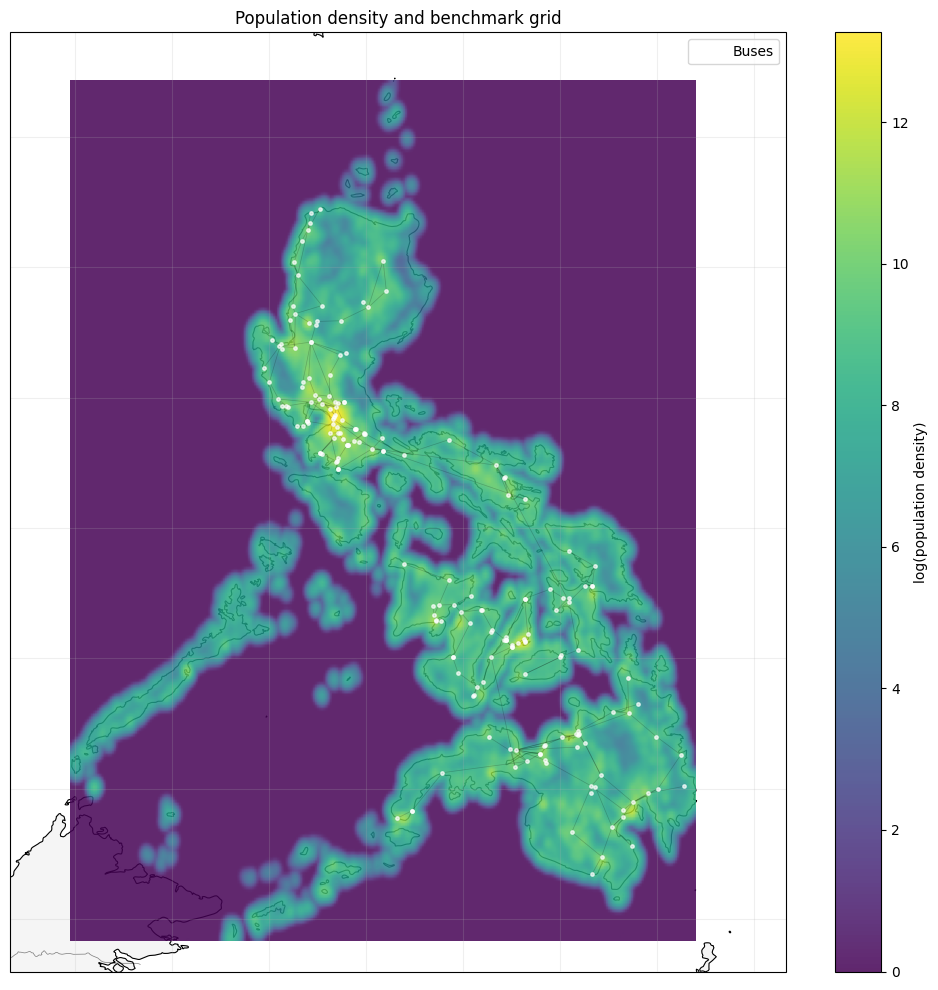

In [77]:
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={"projection": ccrs.PlateCarree()})
setup_ph_map(ax, title="Population density and benchmark grid")

lat_bins = np.linspace(pop_ph["lat"].min(), pop_ph["lat"].max(), 300)
lon_bins = np.linspace(pop_ph["lon"].min(), pop_ph["lon"].max(), 300)
H_pop, yedges_pop, xedges_pop = np.histogram2d(
    pop_ph["lat"],
    pop_ph["lon"],
    bins=[lat_bins, lon_bins],
    weights=pop_ph["pop_value"],
)
H_pop_smooth = gaussian_filter(H_pop, sigma=1.2)
H_pop_log = np.log1p(H_pop_smooth)

im = ax.imshow(
    H_pop_log,
    origin="lower",
    extent=[xedges_pop[0], xedges_pop[-1], yedges_pop[0], yedges_pop[-1]],
    aspect="auto",
    transform=ccrs.PlateCarree(),
    zorder=1,
    alpha=0.85,
)
plot_lines(ax, line_df, color="black", alpha=0.20, linewidth=0.5, zorder=3)
plot_buses(ax, buses_nb, size=6, color="white", alpha=0.7, label="Buses", zorder=4)
plt.colorbar(im, ax=ax, label="log(population density)")
ax.legend()
plt.tight_layout()
plt.show()

GLOBAL_MAX_WIND: 314.84000000000003
Baseline adequacy stats: {'population_proxy': 154555312.94631407, 'gen_capacity_mw': 27013.6, 'mw_per_person_proxy': 0.00017478273302311758}


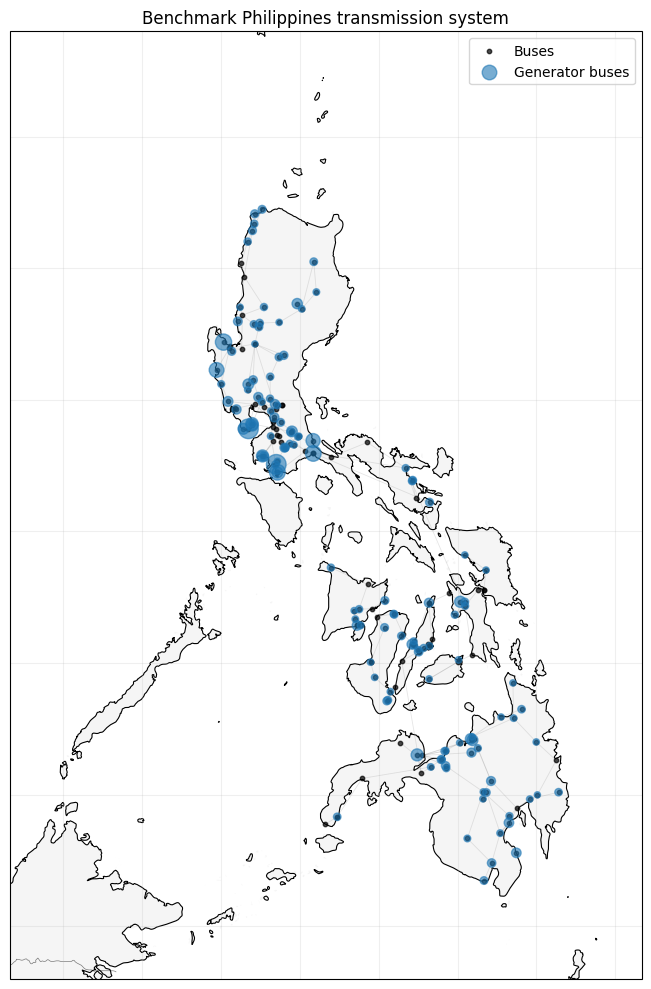

In [78]:
gen_bus_cap = build_generator_bus_capacity(generators=generators, capacity_col=GEN_CAPACITY_COL)
baseline_stats = compute_system_baseline_mw_per_person_proxy(
    G_base=G_base,
    buses=buses_nb,
    gen_bus_cap=gen_bus_cap,
    bus_pop_col="bus_pop_local_nb",
)
GLOBAL_MAX_WIND = ph_points["wind_kph"].max()
if pd.isna(GLOBAL_MAX_WIND) or GLOBAL_MAX_WIND <= 0:
    GLOBAL_MAX_WIND = 1.0

print("GLOBAL_MAX_WIND:", GLOBAL_MAX_WIND)
print("Baseline adequacy stats:", baseline_stats)

gen_bus_plot = buses_nb.merge(gen_bus_cap, on="bus_id", how="left")
gen_bus_plot["gen_capacity_mw"] = gen_bus_plot["gen_capacity_mw"].fillna(0.0)

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={"projection": ccrs.PlateCarree()})
setup_ph_map(ax, title="Benchmark Philippines transmission system")
plot_lines(ax, line_df, color="gray", alpha=0.20, linewidth=0.6, zorder=3)
plot_buses(ax, buses_nb, size=10, color="black", alpha=0.7, label="Buses", zorder=4)

gen_only = gen_bus_plot[gen_bus_plot["gen_capacity_mw"] > 0].copy()
if not gen_only.empty:
    size_scale = 20 + 180 * (gen_only["gen_capacity_mw"] / gen_only["gen_capacity_mw"].max())
    ax.scatter(
        gen_only["lon"], gen_only["lat"], s=size_scale, alpha=0.6,
        label="Generator buses", transform=ccrs.PlateCarree(), zorder=5,
    )
ax.legend()
plt.tight_layout()
plt.show()

## One-storm diagnostics: v4b benchmark vs v5r preferred

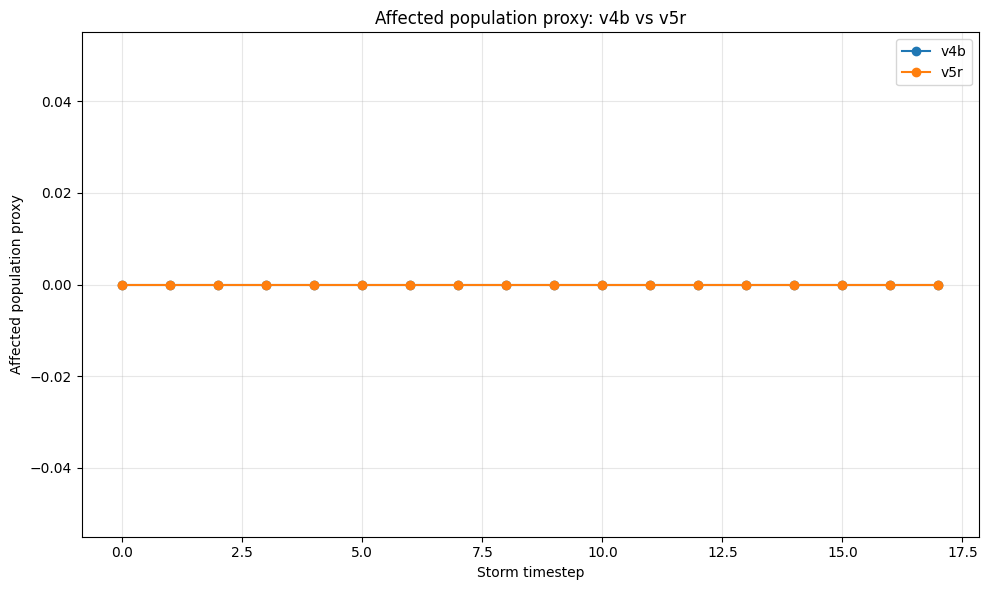

,storm_id,storm_name,year,t,n_track_points_used,n_failed_lines_cumulative,failed_line_share_cumulative,n_unserved_buses,unserved_bus_share,affected_population_proxy,affected_population_share_proxy,n_components,n_served_components,n_unserved_components,max_line_hazard_this_step
0,WP012001,UNNAMED,2001,0,1,0,0.0,0,0.0,0.0,0.0,1,1,0,0.013822
1,WP012001,UNNAMED,2001,1,2,0,0.0,0,0.0,0.0,0.0,1,1,0,0.033556
2,WP012001,UNNAMED,2001,2,3,0,0.0,0,0.0,0.0,0.0,1,1,0,0.146453
3,WP012001,UNNAMED,2001,3,4,0,0.0,0,0.0,0.0,0.0,1,1,0,0.146765
4,WP012001,UNNAMED,2001,4,5,0,0.0,0,0.0,0.0,0.0,1,1,0,0.146765


,storm_id,storm_name,year,t,n_track_points_used,n_failed_lines_cumulative,failed_line_share_cumulative,n_unserved_buses,unserved_bus_share,affected_population_proxy,affected_population_share_proxy,n_components,n_served_components,n_unserved_components,max_line_hazard_this_step
13,WP012001,UNNAMED,2001,13,14,0,0.0,0,0.0,0.0,0.0,1,1,0,0.146765
14,WP012001,UNNAMED,2001,14,15,0,0.0,0,0.0,0.0,0.0,1,1,0,0.146765
15,WP012001,UNNAMED,2001,15,16,0,0.0,0,0.0,0.0,0.0,1,1,0,0.146765
16,WP012001,UNNAMED,2001,16,17,0,0.0,0,0.0,0.0,0.0,1,1,0,0.146765
17,WP012001,UNNAMED,2001,17,18,0,0.0,0,0.0,0.0,0.0,1,1,0,0.146765


In [79]:
storm_id_demo = ph_points["storm_id"].iloc[0]
storm_year_demo = int(ph_points.loc[ph_points["storm_id"] == storm_id_demo, "year"].iloc[0])

gen_buses_demo = get_generator_buses_for_storm_year(
    generators=generators,
    graph_nodes=G_base.nodes(),
    storm_year=storm_year_demo,
    use_commission_year=USE_GENERATOR_COMMISSION_YEAR,
    year_col=GENERATOR_YEAR_COLUMN,
)

ts_demo_v4b, steps_demo_v4b = simulate_grid_impact_timeseries_v4b(
    storm_id=storm_id_demo,
    ph_points=ph_points,
    line_df=line_df,
    line_samples=line_samples,
    buses=buses_nb,
    G_base=G_base,
    gen_buses=gen_buses_demo,
    search_radius_km=SEARCH_RADIUS_KM,
    global_max_wind_kph=GLOBAL_MAX_WIND,
    fail_threshold=FAIL_THRESHOLD,
    rmax_km_default=RMAX_KM_DEFAULT,
    rmax_scaling=RMAX_SCALING,
    inner_core_floor=INNER_CORE_FLOOR,
    outer_decay_power=OUTER_DECAY_POWER,
    min_effective_wind_kph=MIN_EFFECTIVE_WIND_KPH,
    bus_pop_col="bus_pop_local_nb",
)

ts_demo_v5r, steps_demo_v5r = simulate_grid_impact_timeseries_v5r(
    storm_id=storm_id_demo,
    ph_points=ph_points,
    line_df=line_df,
    line_samples=line_samples,
    buses=buses_nb,
    G_base=G_base,
    gen_bus_cap=gen_bus_cap,
    baseline_mw_per_person_proxy=baseline_stats["mw_per_person_proxy"],
    search_radius_km=SEARCH_RADIUS_KM,
    global_max_wind_kph=GLOBAL_MAX_WIND,
    fail_threshold=FAIL_THRESHOLD,
    rmax_km_default=RMAX_KM_DEFAULT,
    rmax_scaling=RMAX_SCALING,
    inner_core_floor=INNER_CORE_FLOOR,
    outer_decay_power=OUTER_DECAY_POWER,
    min_effective_wind_kph=MIN_EFFECTIVE_WIND_KPH,
    bus_pop_col="bus_pop_local_nb",
    min_relative_ratio_multi=MIN_RELATIVE_RATIO_MULTI,
    min_relative_ratio_single=MIN_RELATIVE_RATIO_SINGLE,
    min_total_gen_mw=MIN_TOTAL_GEN_MW,
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(ts_demo_v4b["t"], ts_demo_v4b["affected_population_proxy"], marker="o", label="v4b")
ax.plot(ts_demo_v5r["t"], ts_demo_v5r["affected_population_proxy"], marker="o", label="v5r")
ax.set_title("Affected population proxy: v4b vs v5r")
ax.set_xlabel("Storm timestep")
ax.set_ylabel("Affected population proxy")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

display(ts_demo_v5r.head())
display(ts_demo_v5r.tail())

## Run all storms and rank events

Completed storms:
v4b: 323
v5r deterministic: 323
v5r stochastic: 323


,rank_index,storm_id,storm_name,year,grid_impact_index_v5r,peak_affected_population_proxy,peak_n_failed_lines_cumulative,peak_n_unserved_buses,peak_t
0,1,WP182006,XANGSANE,2006,0.959005,1.620571e+07,41,17,10
1,2,WP312013,HAIYAN,2013,0.836011,1.739417e+07,17,15,2
2,3,WP092014,RAMMASUN,2014,0.525427,1.149723e+07,11,7,4
3,4,WP242006,DURIAN,2006,0.400801,8.042344e+06,13,5,4
4,5,WP282021,RAI,2021,0.380054,7.203793e+06,10,8,2
5,6,WP222020,GONI,2020,0.376411,8.042344e+06,9,5,3
6,7,WP222006,CIMARON,2006,0.276032,5.485862e+06,7,5,7
7,8,WP182022,NORU,2022,0.235911,3.164382e+06,15,4,13
8,9,WP292019,KAMMURI,2019,0.209147,4.588749e+06,4,3,4
9,10,WP072008,FENGSHEN,2008,0.170124,4.499376e+06,1,1,5


,rank_index,storm_id,storm_name,year,grid_impact_index_v5r_stoch,peak_affected_population_proxy,peak_n_failed_lines_cumulative,peak_n_unserved_buses,peak_t
0,1,WP072008,FENGSHEN,2008,0.887755,2.428609e+07,27,20,16
1,2,WP182006,XANGSANE,2006,0.796490,1.665580e+07,49,18,11
2,3,WP312000,BEBINCA,2000,0.757562,1.805601e+07,39,15,19
3,4,WP312013,HAIYAN,2013,0.634068,1.739417e+07,18,15,2
4,5,WP092014,RAMMASUN,2014,0.465627,1.198464e+07,20,9,5
5,6,WP302000,XANGSANE,2000,0.456081,1.037154e+07,23,11,14
6,7,WP302019,PHANFONE,2019,0.447860,1.302704e+07,10,10,15
7,8,WP282021,RAI,2021,0.432792,9.951377e+06,19,12,8
8,9,WP222020,GONI,2020,0.417641,1.126900e+07,17,7,8
9,10,WP242006,DURIAN,2006,0.350585,9.064872e+06,16,6,6


,storm_id,storm_name,year,grid_impact_index_v4b,grid_impact_index_v5r,rank_v4b,rank_v5r,rank_shift,abs_rank_shift
17,WP302019,PHANFONE,2019,0.006098,0.170124,18.0,10.0,8.0,8.0
18,WP072008,FENGSHEN,2008,0.006098,0.170124,18.0,10.0,8.0,8.0
7,WP252020,VAMCO,2020,0.101783,0.061566,8.0,15.0,-7.0,7.0
13,WP262018,MANGKHUT,2018,0.030488,0.030488,12.0,18.0,-6.0,6.0
8,WP242006,DURIAN,2006,0.079268,0.400801,9.0,4.0,5.0,5.0
10,WP222006,CIMARON,2006,0.042683,0.276032,11.0,7.0,4.0,4.0
11,WP112013,UTOR,2013,0.030488,0.059905,12.0,16.0,-4.0,4.0
14,WP242015,KOPPU,2015,0.018293,0.018293,15.0,19.0,-4.0,4.0
5,WP292019,KAMMURI,2019,0.271033,0.209147,6.0,9.0,-3.0,3.0
15,WP152010,MEGI,2010,0.018293,0.151783,15.0,12.0,3.0,3.0


,storm_id,storm_name,year,grid_impact_index_v5r,grid_impact_index_v5r_stoch,rank_v5r_det,rank_v5r_stoch,rank_shift,abs_rank_shift
19,WP202016,MEGI,2016,0.0,0.0,20.0,85.0,-65.0,65.0
20,WP182016,MALAKAS,2016,0.0,0.0,20.0,85.0,-65.0,65.0
21,WP162016,MERANTI,2016,0.0,0.0,20.0,85.0,-65.0,65.0
22,WP152016,NAMTHEUN,2016,0.0,0.0,20.0,85.0,-65.0,65.0
24,WP022016,NEPARTAK,2016,0.0,0.0,20.0,85.0,-65.0,65.0
26,WP222015,MUJIGAE,2015,0.0,0.0,20.0,85.0,-65.0,65.0
27,WP162015,GONI,2015,0.0,0.0,20.0,85.0,-65.0,65.0
28,WP122015,UNNAMED,2015,0.0,0.0,20.0,85.0,-65.0,65.0
29,WP062016,NIDA,2016,0.0,0.0,20.0,85.0,-65.0,65.0
30,WP212017,DOKSURI,2017,0.0,0.0,20.0,85.0,-65.0,65.0


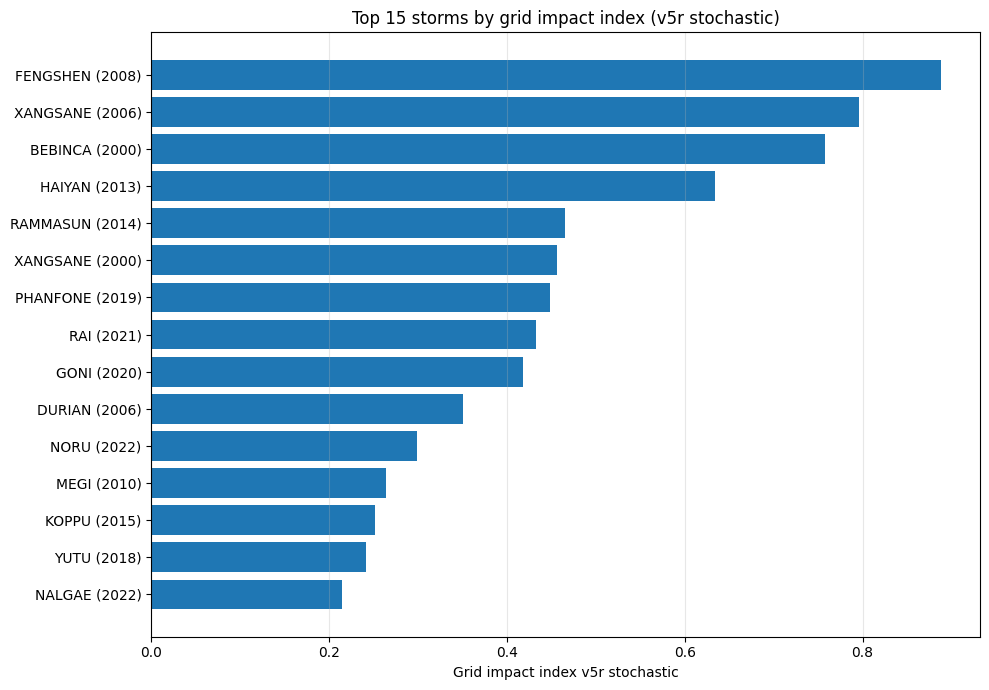

In [80]:
# Run all storms and rank events
# - deterministic v4b
# - deterministic v5r
# - stochastic v5r (one seeded realization per storm)

storm_summaries_v4b = []
storm_summaries_v5r = []
storm_summaries_v5r_stoch = []

storm_ts_store_v4b = {}
storm_ts_store_v5r = {}
storm_ts_store_v5r_stoch = {}

for storm_counter, (_, meta) in enumerate(storm_meta.iterrows()):
    storm_id = meta["storm_id"]
    storm_year = int(meta["year"])

    try:
        gen_buses_y = get_generator_buses_for_storm_year(
            generators=generators,
            graph_nodes=G_base.nodes(),
            storm_year=storm_year,
            use_commission_year=USE_GENERATOR_COMMISSION_YEAR,
            year_col=GENERATOR_YEAR_COLUMN,
        )

        # Deterministic v4b
        ts_df_v4b, _ = simulate_grid_impact_timeseries_v4b(
            storm_id=storm_id,
            ph_points=ph_points,
            line_df=line_df,
            line_samples=line_samples,
            buses=buses_nb,
            G_base=G_base,
            gen_buses=gen_buses_y,
            search_radius_km=SEARCH_RADIUS_KM,
            global_max_wind_kph=GLOBAL_MAX_WIND,
            fail_threshold=FAIL_THRESHOLD,
            rmax_km_default=RMAX_KM_DEFAULT,
            rmax_scaling=RMAX_SCALING,
            inner_core_floor=INNER_CORE_FLOOR,
            outer_decay_power=OUTER_DECAY_POWER,
            min_effective_wind_kph=MIN_EFFECTIVE_WIND_KPH,
            bus_pop_col="bus_pop_local_nb",
        )
        storm_ts_store_v4b[storm_id] = ts_df_v4b.copy()
        storm_summaries_v4b.append(summarize_storm_timeseries(ts_df_v4b))

        # Deterministic v5r
        ts_df_v5r, _ = simulate_grid_impact_timeseries_v5r(
            storm_id=storm_id,
            ph_points=ph_points,
            line_df=line_df,
            line_samples=line_samples,
            buses=buses_nb,
            G_base=G_base,
            gen_bus_cap=gen_bus_cap,
            baseline_mw_per_person_proxy=baseline_stats["mw_per_person_proxy"],
            search_radius_km=SEARCH_RADIUS_KM,
            global_max_wind_kph=GLOBAL_MAX_WIND,
            fail_threshold=FAIL_THRESHOLD,
            rmax_km_default=RMAX_KM_DEFAULT,
            rmax_scaling=RMAX_SCALING,
            inner_core_floor=INNER_CORE_FLOOR,
            outer_decay_power=OUTER_DECAY_POWER,
            min_effective_wind_kph=MIN_EFFECTIVE_WIND_KPH,
            bus_pop_col="bus_pop_local_nb",
            min_relative_ratio_multi=MIN_RELATIVE_RATIO_MULTI,
            min_relative_ratio_single=MIN_RELATIVE_RATIO_SINGLE,
            min_total_gen_mw=MIN_TOTAL_GEN_MW,
        )
        storm_ts_store_v5r[storm_id] = ts_df_v5r.copy()
        storm_summaries_v5r.append(summarize_storm_timeseries(ts_df_v5r))

        # Stochastic v5r: one reproducible draw per storm
        rng_storm = np.random.default_rng(10000 + storm_counter)

        ts_df_v5r_stoch, _ = simulate_grid_impact_timeseries_v5r_stochastic(
            storm_id=storm_id,
            ph_points=ph_points,
            line_df=line_df,
            line_samples=line_samples,
            buses=buses_nb,
            G_base=G_base,
            gen_bus_cap=gen_bus_cap,
            baseline_mw_per_person_proxy=baseline_stats["mw_per_person_proxy"],
            search_radius_km=SEARCH_RADIUS_KM,
            global_max_wind_kph=GLOBAL_MAX_WIND,
            fragility_h0=FAIL_THRESHOLD,
            fragility_k=18.0,
            rmax_km_default=RMAX_KM_DEFAULT,
            rmax_scaling=RMAX_SCALING,
            inner_core_floor=INNER_CORE_FLOOR,
            outer_decay_power=OUTER_DECAY_POWER,
            min_effective_wind_kph=MIN_EFFECTIVE_WIND_KPH,
            bus_pop_col="bus_pop_local_nb",
            min_relative_ratio_multi=MIN_RELATIVE_RATIO_MULTI,
            min_relative_ratio_single=MIN_RELATIVE_RATIO_SINGLE,
            min_total_gen_mw=MIN_TOTAL_GEN_MW,
            rng=rng_storm,
        )
        storm_ts_store_v5r_stoch[storm_id] = ts_df_v5r_stoch.copy()
        storm_summaries_v5r_stoch.append(summarize_storm_timeseries(ts_df_v5r_stoch))

    except Exception as exc:
        print(f"Skipping {storm_id}: {exc}")

rank_df_v4b = pd.DataFrame(storm_summaries_v4b)
rank_df_v5r = pd.DataFrame(storm_summaries_v5r)
rank_df_v5r_stoch = pd.DataFrame(storm_summaries_v5r_stoch)

for df, metric_name in [
    (rank_df_v4b, "grid_impact_index_v4b"),
    (rank_df_v5r, "grid_impact_index_v5r"),
    (rank_df_v5r_stoch, "grid_impact_index_v5r_stoch"),
]:
    if df.empty:
        continue

    df["peak_affected_population_proxy_norm"] = minmax_normalize(df["peak_affected_population_proxy"])
    df["peak_n_failed_lines_norm"] = minmax_normalize(df["peak_n_failed_lines_cumulative"])
    df["peak_n_unserved_buses_norm"] = minmax_normalize(df["peak_n_unserved_buses"])

    df[metric_name] = (
        0.60 * df["peak_affected_population_proxy_norm"]
        + 0.25 * df["peak_n_failed_lines_norm"]
        + 0.15 * df["peak_n_unserved_buses_norm"]
    )

    df.sort_values(metric_name, ascending=False, inplace=True)
    df.reset_index(drop=True, inplace=True)
    df["rank_index"] = df.index + 1

print("Completed storms:")
print("v4b:", len(rank_df_v4b))
print("v5r deterministic:", len(rank_df_v5r))
print("v5r stochastic:", len(rank_df_v5r_stoch))

display(
    rank_df_v5r[
        [
            "rank_index",
            "storm_id",
            "storm_name",
            "year",
            "grid_impact_index_v5r",
            "peak_affected_population_proxy",
            "peak_n_failed_lines_cumulative",
            "peak_n_unserved_buses",
            "peak_t",
        ]
    ].head(25)
)

display(
    rank_df_v5r_stoch[
        [
            "rank_index",
            "storm_id",
            "storm_name",
            "year",
            "grid_impact_index_v5r_stoch",
            "peak_affected_population_proxy",
            "peak_n_failed_lines_cumulative",
            "peak_n_unserved_buses",
            "peak_t",
        ]
    ].head(25)
)

compare_v4b_v5r = rank_df_v4b[
    ["storm_id", "storm_name", "year", "grid_impact_index_v4b"]
].merge(
    rank_df_v5r[["storm_id", "grid_impact_index_v5r"]],
    on="storm_id",
    how="inner",
)

compare_v4b_v5r["rank_v4b"] = compare_v4b_v5r["grid_impact_index_v4b"].rank(
    ascending=False,
    method="min",
)
compare_v4b_v5r["rank_v5r"] = compare_v4b_v5r["grid_impact_index_v5r"].rank(
    ascending=False,
    method="min",
)
compare_v4b_v5r["rank_shift"] = compare_v4b_v5r["rank_v4b"] - compare_v4b_v5r["rank_v5r"]
compare_v4b_v5r["abs_rank_shift"] = compare_v4b_v5r["rank_shift"].abs()

display(
    compare_v4b_v5r.sort_values(
        ["abs_rank_shift", "rank_v5r"],
        ascending=[False, True],
    ).head(30)
)

compare_det_stoch = rank_df_v5r[
    ["storm_id", "storm_name", "year", "grid_impact_index_v5r"]
].merge(
    rank_df_v5r_stoch[["storm_id", "grid_impact_index_v5r_stoch"]],
    on="storm_id",
    how="inner",
)

compare_det_stoch["rank_v5r_det"] = compare_det_stoch["grid_impact_index_v5r"].rank(
    ascending=False,
    method="min",
)
compare_det_stoch["rank_v5r_stoch"] = compare_det_stoch["grid_impact_index_v5r_stoch"].rank(
    ascending=False,
    method="min",
)
compare_det_stoch["rank_shift"] = (
    compare_det_stoch["rank_v5r_det"] - compare_det_stoch["rank_v5r_stoch"]
)
compare_det_stoch["abs_rank_shift"] = compare_det_stoch["rank_shift"].abs()

display(
    compare_det_stoch.sort_values(
        ["abs_rank_shift", "rank_v5r_stoch"],
        ascending=[False, True],
    ).head(30)
)

fig, ax = plt.subplots(figsize=(10, 7))
plot_df = rank_df_v5r_stoch.head(15).sort_values("grid_impact_index_v5r_stoch")
labels = plot_df["storm_name"] + " (" + plot_df["year"].astype(int).astype(str) + ")"
ax.barh(labels, plot_df["grid_impact_index_v5r_stoch"])
ax.set_title("Top 15 storms by grid impact index (v5r stochastic)")
ax.set_xlabel("Grid impact index v5r stochastic")
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

,storm_id,storm_name,year,grid_impact_index_v4b,grid_impact_index_v5r,rank_v4b,rank_v5r,rank_shift,abs_rank_shift
17,WP302019,PHANFONE,2019,0.006098,0.170124,18.0,10.0,8.0,8.0
18,WP072008,FENGSHEN,2008,0.006098,0.170124,18.0,10.0,8.0,8.0
7,WP252020,VAMCO,2020,0.101783,0.061566,8.0,15.0,-7.0,7.0
13,WP262018,MANGKHUT,2018,0.030488,0.030488,12.0,18.0,-6.0,6.0
8,WP242006,DURIAN,2006,0.079268,0.400801,9.0,4.0,5.0,5.0
10,WP222006,CIMARON,2006,0.042683,0.276032,11.0,7.0,4.0,4.0
11,WP112013,UTOR,2013,0.030488,0.059905,12.0,16.0,-4.0,4.0
14,WP242015,KOPPU,2015,0.018293,0.018293,15.0,19.0,-4.0,4.0
5,WP292019,KAMMURI,2019,0.271033,0.209147,6.0,9.0,-3.0,3.0
15,WP152010,MEGI,2010,0.018293,0.151783,15.0,12.0,3.0,3.0


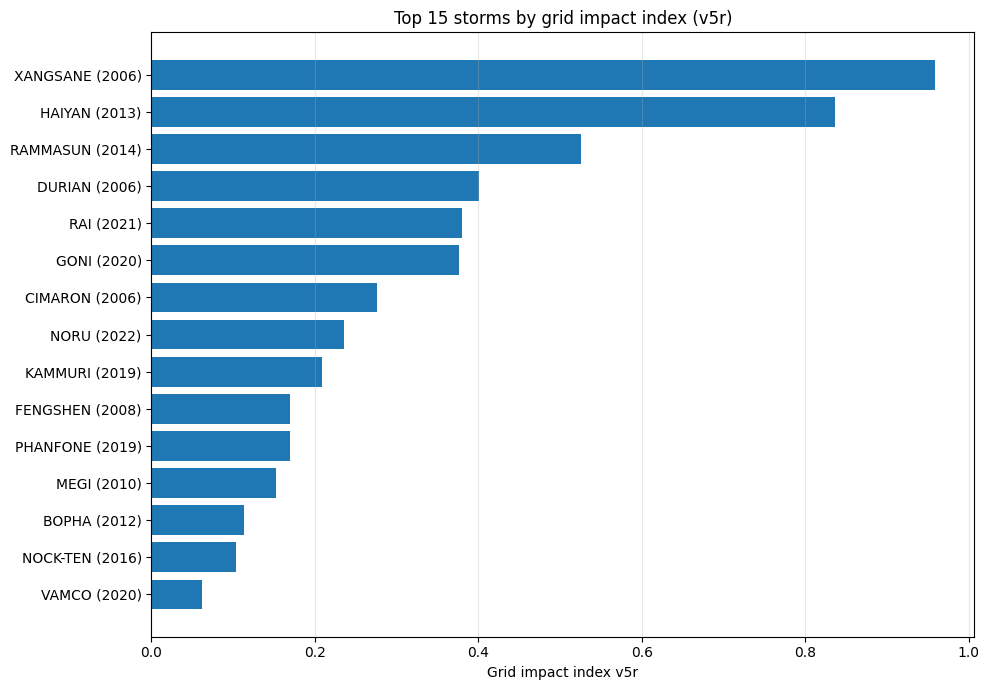

In [81]:
compare_v4b_v5r = rank_df_v4b[
    ["storm_id", "storm_name", "year", "grid_impact_index_v4b"]
].merge(
    rank_df_v5r[["storm_id", "grid_impact_index_v5r"]],
    on="storm_id",
    how="inner",
)

compare_v4b_v5r["rank_v4b"] = compare_v4b_v5r["grid_impact_index_v4b"].rank(ascending=False, method="min")
compare_v4b_v5r["rank_v5r"] = compare_v4b_v5r["grid_impact_index_v5r"].rank(ascending=False, method="min")
compare_v4b_v5r["rank_shift"] = compare_v4b_v5r["rank_v4b"] - compare_v4b_v5r["rank_v5r"]
compare_v4b_v5r["abs_rank_shift"] = compare_v4b_v5r["rank_shift"].abs()
display(compare_v4b_v5r.sort_values(["abs_rank_shift", "rank_v5r"], ascending=[False, True]).head(30))

fig, ax = plt.subplots(figsize=(10, 7))
plot_df = rank_df_v5r.head(15).sort_values("grid_impact_index_v5r")
labels = plot_df["storm_name"] + " (" + plot_df["year"].astype(int).astype(str) + ")"
ax.barh(labels, plot_df["grid_impact_index_v5r"])
ax.set_title("Top 15 storms by grid impact index (v5r)")
ax.set_xlabel("Grid impact index v5r")
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

Running stochastic simulation for storm: WP012001


,storm_id,storm_name,year,t,n_track_points_used,n_failed_lines_cumulative,failed_line_share_cumulative,n_failed_lines_new,n_unserved_buses,unserved_bus_share,affected_population_proxy,affected_population_share_proxy,n_components,n_served_components,n_unserved_components,max_line_hazard_this_step,mean_line_p_fail_this_step,max_line_p_fail_this_step
0,WP012001,UNNAMED,2001,0,1,0,0.0,0,0,0.0,0.0,0.0,1,1,0,0.013822,0.000050,0.000064
1,WP012001,UNNAMED,2001,1,2,0,0.0,0,0,0.0,0.0,0.0,1,1,0,0.033556,0.000052,0.000092
2,WP012001,UNNAMED,2001,2,3,0,0.0,0,0,0.0,0.0,0.0,1,1,0,0.146453,0.000079,0.000700
3,WP012001,UNNAMED,2001,3,4,0,0.0,0,0,0.0,0.0,0.0,1,1,0,0.146765,0.000090,0.000704
4,WP012001,UNNAMED,2001,4,5,0,0.0,0,0,0.0,0.0,0.0,1,1,0,0.146765,0.000099,0.000704


,storm_id,storm_name,year,t,n_track_points_used,n_failed_lines_cumulative,failed_line_share_cumulative,n_failed_lines_new,n_unserved_buses,unserved_bus_share,affected_population_proxy,affected_population_share_proxy,n_components,n_served_components,n_unserved_components,max_line_hazard_this_step,mean_line_p_fail_this_step,max_line_p_fail_this_step
13,WP012001,UNNAMED,2001,13,14,0,0.0,0,0,0.0,0.0,0.0,1,1,0,0.146765,0.000109,0.000704
14,WP012001,UNNAMED,2001,14,15,0,0.0,0,0,0.0,0.0,0.0,1,1,0,0.146765,0.000110,0.000704
15,WP012001,UNNAMED,2001,15,16,0,0.0,0,0,0.0,0.0,0.0,1,1,0,0.146765,0.000112,0.000704
16,WP012001,UNNAMED,2001,16,17,0,0.0,0,0,0.0,0.0,0.0,1,1,0,0.146765,0.000113,0.000704
17,WP012001,UNNAMED,2001,17,18,0,0.0,0,0,0.0,0.0,0.0,1,1,0,0.146765,0.000113,0.000704


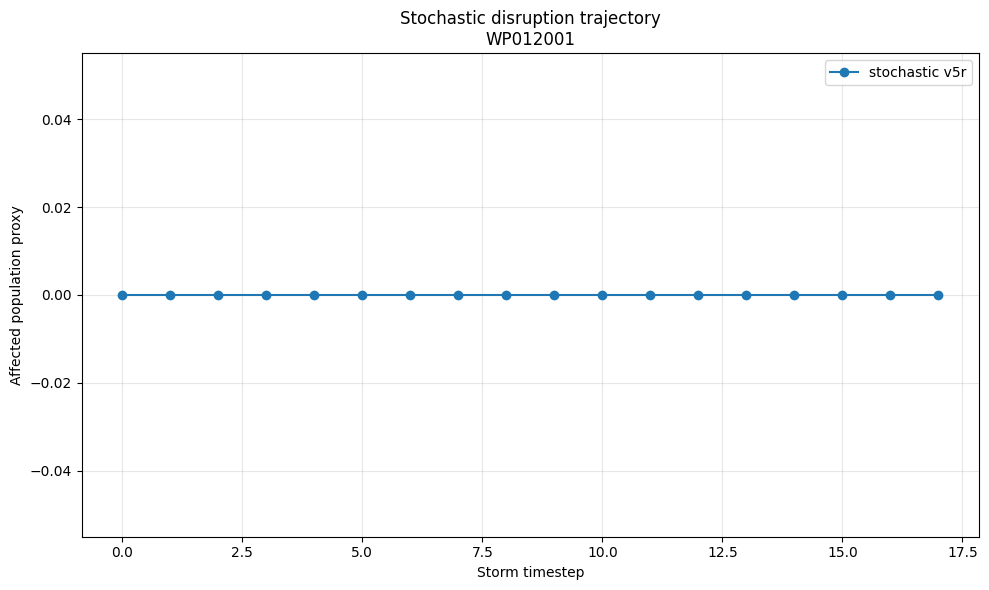

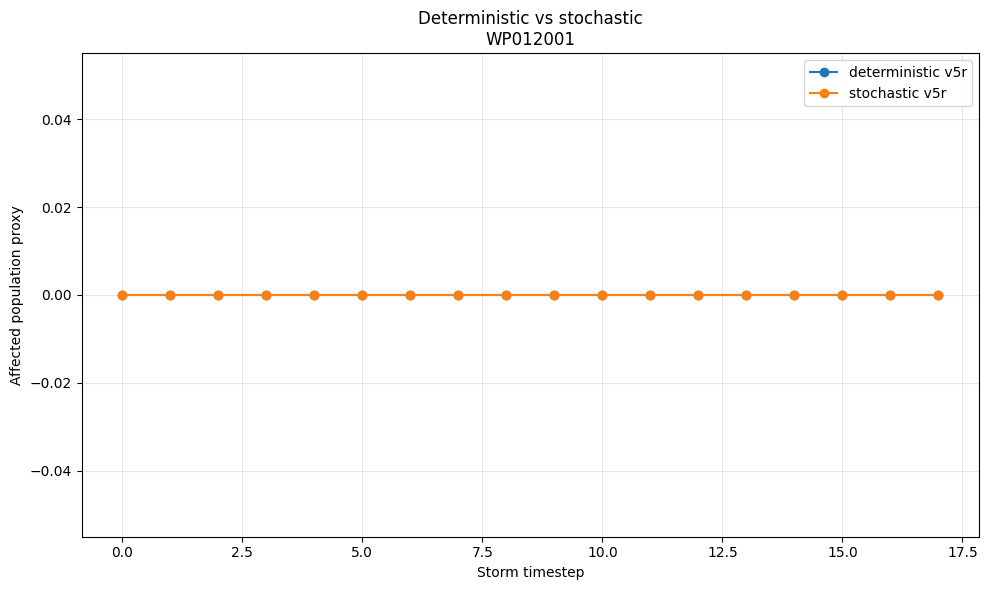

Running ensemble for storm: WP012001 (N=100)

--- Ensemble Results: Peak affected population proxy ---
Mean: 480,253
Std:  1,769,944
P10:  0
P50:  0
P90:  67,706


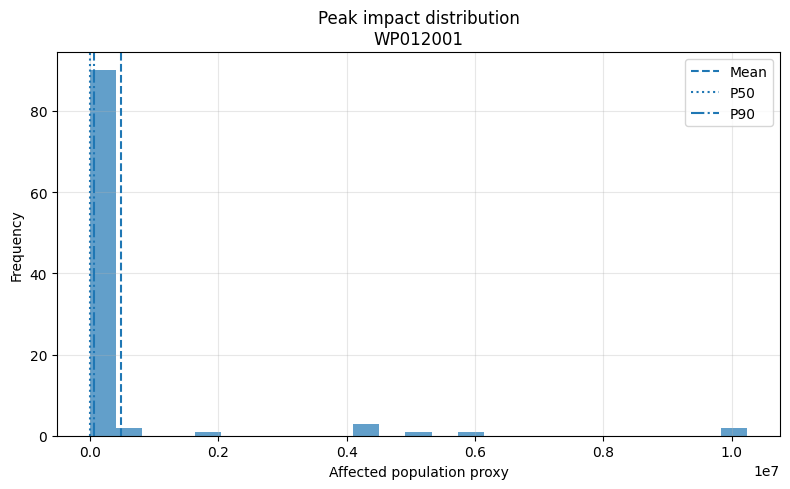

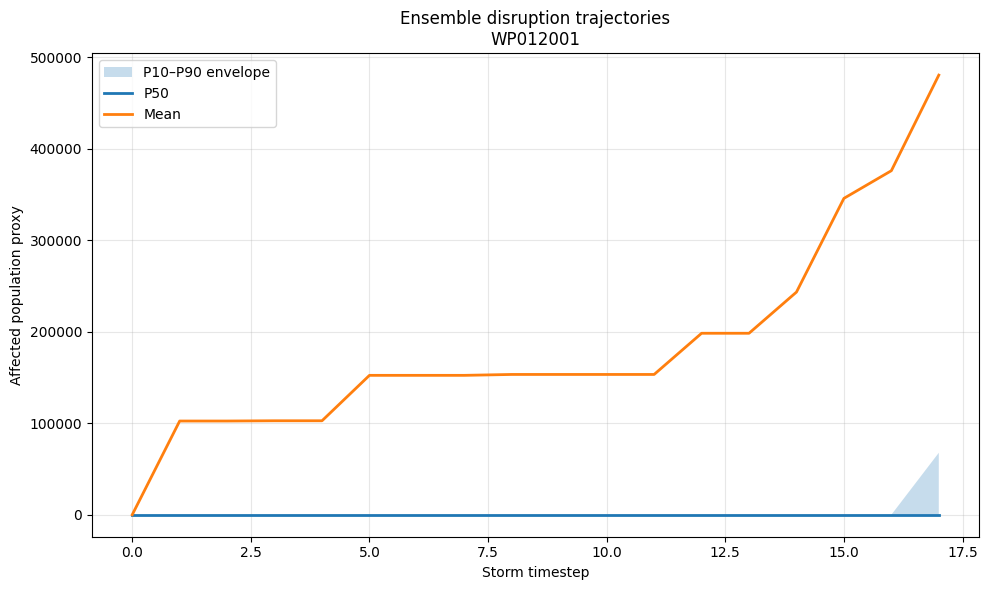

,storm_id,n_runs,mean_peak_affected_population_proxy,std_peak_affected_population_proxy,p10_peak_affected_population_proxy,p50_peak_affected_population_proxy,p90_peak_affected_population_proxy,deterministic_peak_affected_population_proxy,stochastic_demo_peak_affected_population_proxy
0,WP012001,100,480252.549282,1.769944e+06,0.0,0.0,67705.578582,0.0,0.0


In [82]:
# Stochastic demo for one storm + ensemble experiment

storm_id_demo = ph_points["storm_id"].iloc[0]
print("Running stochastic simulation for storm:", storm_id_demo)

# One reproducible stochastic run
rng_demo = np.random.default_rng(123)

ts_demo_stoch, steps_demo_stoch = simulate_grid_impact_timeseries_v5r_stochastic(
    storm_id=storm_id_demo,
    ph_points=ph_points,
    line_df=line_df,
    line_samples=line_samples,
    buses=buses_nb,
    G_base=G_base,
    gen_bus_cap=gen_bus_cap,
    baseline_mw_per_person_proxy=baseline_stats["mw_per_person_proxy"],
    search_radius_km=SEARCH_RADIUS_KM,
    global_max_wind_kph=GLOBAL_MAX_WIND,
    fragility_h0=FAIL_THRESHOLD,
    fragility_k=18.0,
    rmax_km_default=RMAX_KM_DEFAULT,
    rmax_scaling=RMAX_SCALING,
    inner_core_floor=INNER_CORE_FLOOR,
    outer_decay_power=OUTER_DECAY_POWER,
    min_effective_wind_kph=MIN_EFFECTIVE_WIND_KPH,
    bus_pop_col="bus_pop_local_nb",
    min_relative_ratio_multi=MIN_RELATIVE_RATIO_MULTI,
    min_relative_ratio_single=MIN_RELATIVE_RATIO_SINGLE,
    min_total_gen_mw=MIN_TOTAL_GEN_MW,
    rng=rng_demo,
)

display(ts_demo_stoch.head())
display(ts_demo_stoch.tail())

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(
    ts_demo_stoch["t"],
    ts_demo_stoch["affected_population_proxy"],
    marker="o",
    label="stochastic v5r",
)
ax.set_title(f"Stochastic disruption trajectory\n{storm_id_demo}")
ax.set_xlabel("Storm timestep")
ax.set_ylabel("Affected population proxy")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

# Deterministic vs stochastic comparison for same storm
ts_demo_det, _ = simulate_grid_impact_timeseries_v5r(
    storm_id=storm_id_demo,
    ph_points=ph_points,
    line_df=line_df,
    line_samples=line_samples,
    buses=buses_nb,
    G_base=G_base,
    gen_bus_cap=gen_bus_cap,
    baseline_mw_per_person_proxy=baseline_stats["mw_per_person_proxy"],
    search_radius_km=SEARCH_RADIUS_KM,
    global_max_wind_kph=GLOBAL_MAX_WIND,
    fail_threshold=FAIL_THRESHOLD,
    rmax_km_default=RMAX_KM_DEFAULT,
    rmax_scaling=RMAX_SCALING,
    inner_core_floor=INNER_CORE_FLOOR,
    outer_decay_power=OUTER_DECAY_POWER,
    min_effective_wind_kph=MIN_EFFECTIVE_WIND_KPH,
    bus_pop_col="bus_pop_local_nb",
    min_relative_ratio_multi=MIN_RELATIVE_RATIO_MULTI,
    min_relative_ratio_single=MIN_RELATIVE_RATIO_SINGLE,
    min_total_gen_mw=MIN_TOTAL_GEN_MW,
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(
    ts_demo_det["t"],
    ts_demo_det["affected_population_proxy"],
    marker="o",
    label="deterministic v5r",
)
ax.plot(
    ts_demo_stoch["t"],
    ts_demo_stoch["affected_population_proxy"],
    marker="o",
    label="stochastic v5r",
)
ax.set_title(f"Deterministic vs stochastic\n{storm_id_demo}")
ax.set_xlabel("Storm timestep")
ax.set_ylabel("Affected population proxy")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

# Ensemble for one storm
N_RUNS = 100
print(f"Running ensemble for storm: {storm_id_demo} (N={N_RUNS})")

peak_impacts = []
final_impacts = []
all_runs_ts = []

for i in range(N_RUNS):
    rng_i = np.random.default_rng(1000 + i)

    ts_i, _ = simulate_grid_impact_timeseries_v5r_stochastic(
        storm_id=storm_id_demo,
        ph_points=ph_points,
        line_df=line_df,
        line_samples=line_samples,
        buses=buses_nb,
        G_base=G_base,
        gen_bus_cap=gen_bus_cap,
        baseline_mw_per_person_proxy=baseline_stats["mw_per_person_proxy"],
        search_radius_km=SEARCH_RADIUS_KM,
        global_max_wind_kph=GLOBAL_MAX_WIND,
        fragility_h0=FAIL_THRESHOLD,
        fragility_k=18.0,
        rmax_km_default=RMAX_KM_DEFAULT,
        rmax_scaling=RMAX_SCALING,
        inner_core_floor=INNER_CORE_FLOOR,
        outer_decay_power=OUTER_DECAY_POWER,
        min_effective_wind_kph=MIN_EFFECTIVE_WIND_KPH,
        bus_pop_col="bus_pop_local_nb",
        min_relative_ratio_multi=MIN_RELATIVE_RATIO_MULTI,
        min_relative_ratio_single=MIN_RELATIVE_RATIO_SINGLE,
        min_total_gen_mw=MIN_TOTAL_GEN_MW,
        rng=rng_i,
    )

    peak_impacts.append(ts_i["affected_population_proxy"].max())
    final_impacts.append(ts_i.iloc[-1]["affected_population_proxy"])
    all_runs_ts.append(ts_i.copy())

peak_impacts = np.array(peak_impacts, dtype=float)
final_impacts = np.array(final_impacts, dtype=float)

mean_peak = peak_impacts.mean()
std_peak = peak_impacts.std()
p10_peak = np.percentile(peak_impacts, 10)
p50_peak = np.percentile(peak_impacts, 50)
p90_peak = np.percentile(peak_impacts, 90)

print("\n--- Ensemble Results: Peak affected population proxy ---")
print(f"Mean: {mean_peak:,.0f}")
print(f"Std:  {std_peak:,.0f}")
print(f"P10:  {p10_peak:,.0f}")
print(f"P50:  {p50_peak:,.0f}")
print(f"P90:  {p90_peak:,.0f}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(peak_impacts, bins=25, alpha=0.7)
ax.axvline(mean_peak, linestyle="--", label="Mean")
ax.axvline(p50_peak, linestyle=":", label="P50")
ax.axvline(p90_peak, linestyle="-.", label="P90")
ax.set_title(f"Peak impact distribution\n{storm_id_demo}")
ax.set_xlabel("Affected population proxy")
ax.set_ylabel("Frequency")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

# Ensemble trajectories with percentile envelope
all_ts_concat = pd.concat(
    [
        ts.assign(run_id=i)[["run_id", "t", "affected_population_proxy"]]
        for i, ts in enumerate(all_runs_ts)
    ],
    ignore_index=True,
)

traj_summary = (
    all_ts_concat.groupby("t")["affected_population_proxy"]
    .agg(
        p10=lambda x: np.percentile(x, 10),
        p50=lambda x: np.percentile(x, 50),
        p90=lambda x: np.percentile(x, 90),
        mean="mean",
    )
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.fill_between(
    traj_summary["t"],
    traj_summary["p10"],
    traj_summary["p90"],
    alpha=0.25,
    label="P10–P90 envelope",
)
ax.plot(traj_summary["t"], traj_summary["p50"], linewidth=2, label="P50")
ax.plot(traj_summary["t"], traj_summary["mean"], linewidth=2, label="Mean")
ax.set_title(f"Ensemble disruption trajectories\n{storm_id_demo}")
ax.set_xlabel("Storm timestep")
ax.set_ylabel("Affected population proxy")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

ensemble_summary_demo = pd.DataFrame(
    {
        "storm_id": [storm_id_demo],
        "n_runs": [N_RUNS],
        "mean_peak_affected_population_proxy": [mean_peak],
        "std_peak_affected_population_proxy": [std_peak],
        "p10_peak_affected_population_proxy": [p10_peak],
        "p50_peak_affected_population_proxy": [p50_peak],
        "p90_peak_affected_population_proxy": [p90_peak],
        "deterministic_peak_affected_population_proxy": [
            ts_demo_det["affected_population_proxy"].max()
        ],
        "stochastic_demo_peak_affected_population_proxy": [
            ts_demo_stoch["affected_population_proxy"].max()
        ],
    }
)

display(ensemble_summary_demo)

**ensemble simulation for one storm**

In [83]:
# --- Ensemble settings ---
N_RUNS = 100  # increase to 200–500 later

storm_id_demo = ph_points["storm_id"].iloc[0]

print(f"Running ensemble for storm: {storm_id_demo} (N={N_RUNS})")

peak_impacts = []
all_runs_ts = []

# --- Run ensemble ---
for i in range(N_RUNS):
    rng_i = np.random.default_rng(1000 + i)

    ts_i, _ = simulate_grid_impact_timeseries_v5r_stochastic(
        storm_id=storm_id_demo,
        ph_points=ph_points,
        line_df=line_df,
        line_samples=line_samples,
        buses=buses_nb,
        G_base=G_base,
        gen_bus_cap=gen_bus_cap,
        baseline_mw_per_person_proxy=baseline_stats["mw_per_person_proxy"],
        search_radius_km=SEARCH_RADIUS_KM,
        global_max_wind_kph=GLOBAL_MAX_WIND,
        fragility_h0=0.50,
        fragility_k=6.0,
        rmax_km_default=RMAX_KM_DEFAULT,
        rmax_scaling=RMAX_SCALING,
        inner_core_floor=INNER_CORE_FLOOR,
        outer_decay_power=OUTER_DECAY_POWER,
        min_effective_wind_kph=MIN_EFFECTIVE_WIND_KPH,
        bus_pop_col="bus_pop_local_nb",
        min_relative_ratio_multi=MIN_RELATIVE_RATIO_MULTI,
        min_relative_ratio_single=MIN_RELATIVE_RATIO_SINGLE,
        min_total_gen_mw=MIN_TOTAL_GEN_MW,
        rng=rng_i,
    )

    peak_impacts.append(ts_i["affected_population_proxy"].max())
    all_runs_ts.append(ts_i)

# --- Convert to array ---
peak_impacts = np.array(peak_impacts)

# --- Summary stats ---
mean_impact = peak_impacts.mean()
std_impact = peak_impacts.std()
p50 = np.percentile(peak_impacts, 50)
p90 = np.percentile(peak_impacts, 90)

print("\n--- Ensemble Results ---")
print(f"Mean impact: {mean_impact:,.0f}")
print(f"Std dev:     {std_impact:,.0f}")
print(f"P50 impact:  {p50:,.0f}")
print(f"P90 impact:  {p90:,.0f}")

Running ensemble for storm: WP012001 (N=100)



--- Ensemble Results ---
Mean impact: 77,791,728
Std dev:     9,810,956
P50 impact:  77,850,644
P90 impact:  91,585,684


**Distribution Plot (critical insight)**

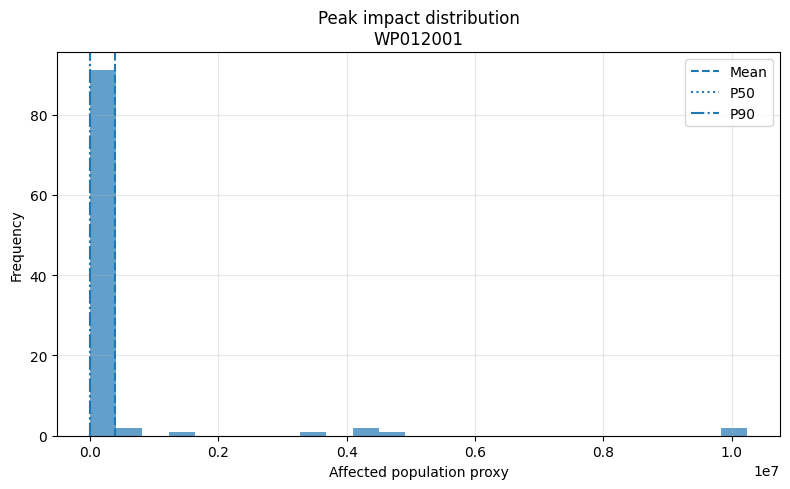

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(peak_impacts, bins=25, alpha=0.7)

ax.axvline(mean_impact, linestyle="--", label="Mean")
ax.axvline(p50, linestyle=":", label="P50")
ax.axvline(p90, linestyle="-.", label="P90")

ax.set_title(f"Peak impact distribution\n{storm_id_demo}")
ax.set_xlabel("Affected population proxy")
ax.set_ylabel("Frequency")

ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Top-event dynamic animation and peak footprint

Top deterministic v5r storm: WP182006
Top stochastic v5r storm: WP072008


,storm_id,storm_name,year,t,n_track_points_used,n_failed_lines_cumulative,failed_line_share_cumulative,n_failed_lines_new,n_unserved_buses,unserved_bus_share,affected_population_proxy,affected_population_share_proxy,n_components,n_served_components,n_unserved_components,max_line_hazard_this_step,mean_line_p_fail_this_step,max_line_p_fail_this_step
0,WP072008,FENGSHEN,2008,0,1,0,0.000000,0,0,0.000000,0.0,0.0,1,1,0,0.000000,0.000050,0.000050
1,WP072008,FENGSHEN,2008,1,2,0,0.000000,0,0,0.000000,0.0,0.0,1,1,0,0.050094,0.000052,0.000124
2,WP072008,FENGSHEN,2008,2,3,1,0.004237,1,1,0.005208,0.0,0.0,2,1,1,0.440243,0.002111,0.121786
3,WP072008,FENGSHEN,2008,3,4,1,0.004237,0,1,0.005208,0.0,0.0,2,1,1,0.470074,0.004294,0.191750
4,WP072008,FENGSHEN,2008,4,5,2,0.008475,1,1,0.005208,0.0,0.0,3,2,1,0.470074,0.004366,0.191750


,storm_id,storm_name,year,t,n_track_points_used,n_failed_lines_cumulative,failed_line_share_cumulative,n_failed_lines_new,n_unserved_buses,unserved_bus_share,affected_population_proxy,affected_population_share_proxy,n_components,n_served_components,n_unserved_components,max_line_hazard_this_step,mean_line_p_fail_this_step,max_line_p_fail_this_step
12,WP072008,FENGSHEN,2008,12,13,21,0.088983,5,11,0.057292,2.000371e+07,0.129427,15,6,9,0.60956,0.026947,0.744991
13,WP072008,FENGSHEN,2008,13,14,22,0.093220,1,11,0.057292,2.000371e+07,0.129427,16,7,9,0.60956,0.026947,0.744991
14,WP072008,FENGSHEN,2008,14,15,23,0.097458,1,11,0.057292,2.000371e+07,0.129427,16,7,9,0.60956,0.026947,0.744991
15,WP072008,FENGSHEN,2008,15,16,24,0.101695,1,11,0.057292,2.000371e+07,0.129427,17,8,9,0.60956,0.026947,0.744991
16,WP072008,FENGSHEN,2008,16,17,26,0.110169,2,12,0.062500,2.083117e+07,0.134781,18,8,10,0.60956,0.026947,0.744991


Saved animation to: /home/krawalker/coding/KRITIS-PH/outputs/storm_animation_top_stochastic_WP072008.gif
Saved animation: /home/krawalker/coding/KRITIS-PH/outputs/storm_animation_top_stochastic_WP072008.gif


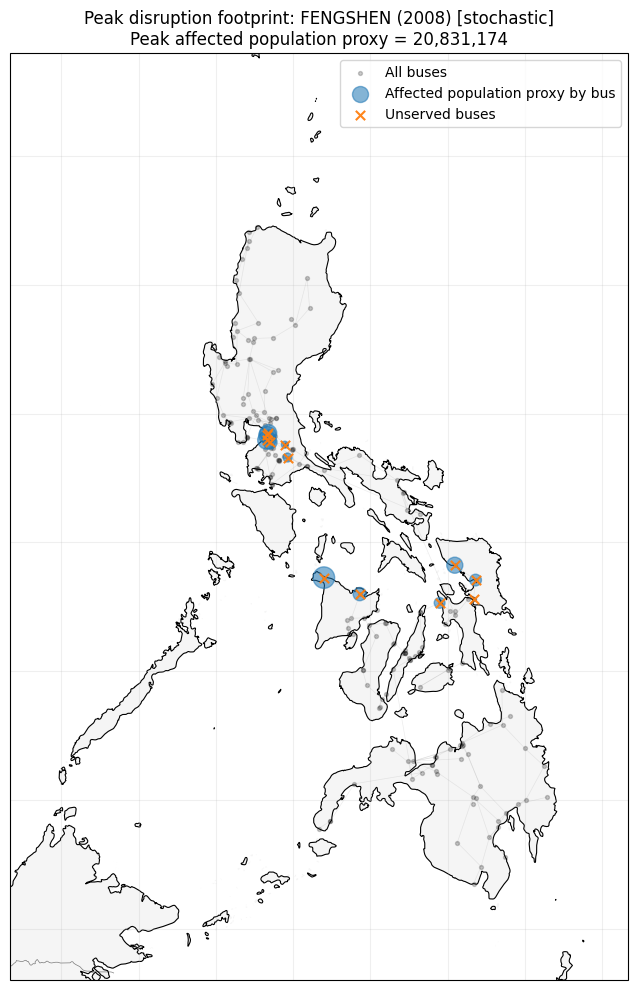

,bus_id,unserved,bus_pop_local_nb,affected_population_proxy,n_affected_cells
145,08NABAS,True,4.499376e+06,4.499376e+06,16916
60,02ZAPOTE,True,3.117837e+06,3.117837e+06,193
57,02MANILA,True,2.783354e+06,2.783354e+06,110
56,02DONAIMELDA,True,2.621333e+06,2.621333e+06,88
97,04CALBAYOG,True,2.327941e+06,2.327941e+06,7898
58,02MUNTINLUPA,True,1.605273e+06,1.605273e+06,102
146,08PANITAN,True,1.443907e+06,1.443907e+06,3400
102,04PARANAS,True,1.056476e+06,1.056476e+06,6060
105,04TABANGO,True,8.274684e+05,8.274684e+05,1666
86,03PALAYAN,True,4.393862e+05,4.393862e+05,557


,component_id,bus_ids,n_buses,n_generator_buses,population_proxy,gen_capacity_mw,mw_per_person_proxy,relative_adequacy,required_relative_ratio,served_component,service_ratio
0,6,"[02DONAIMELDA, 02MANILA]",2,0,5.404687e+06,0.0,0.000000,0.000000,0.35,False,0.000000
1,17,[08NABAS],1,1,4.499376e+06,74.1,0.000016,0.094225,0.75,False,0.094225
2,13,"[04CALBAYOG, 04PARANAS]",2,2,3.384418e+06,26.2,0.000008,0.044291,0.35,False,0.044291
3,8,[02ZAPOTE],1,0,3.117837e+06,0.0,0.000000,0.000000,0.75,False,0.000000
4,7,[02MUNTINLUPA],1,0,1.605273e+06,0.0,0.000000,0.000000,0.75,False,0.000000
5,18,[08PANITAN],1,0,1.443907e+06,0.0,0.000000,0.000000,0.75,False,0.000000
6,15,[04TABANGO],1,0,8.274684e+05,0.0,0.000000,0.000000,0.75,False,0.000000
7,12,[03PALAYAN],1,1,4.393862e+05,31.0,0.000071,0.403661,0.75,False,0.403661
8,4,[01BPC],1,0,1.088207e+05,0.0,0.000000,0.000000,0.75,False,0.000000
9,14,[04STARITA],1,0,0.000000e+00,0.0,NaN,NaN,0.75,False,0.000000


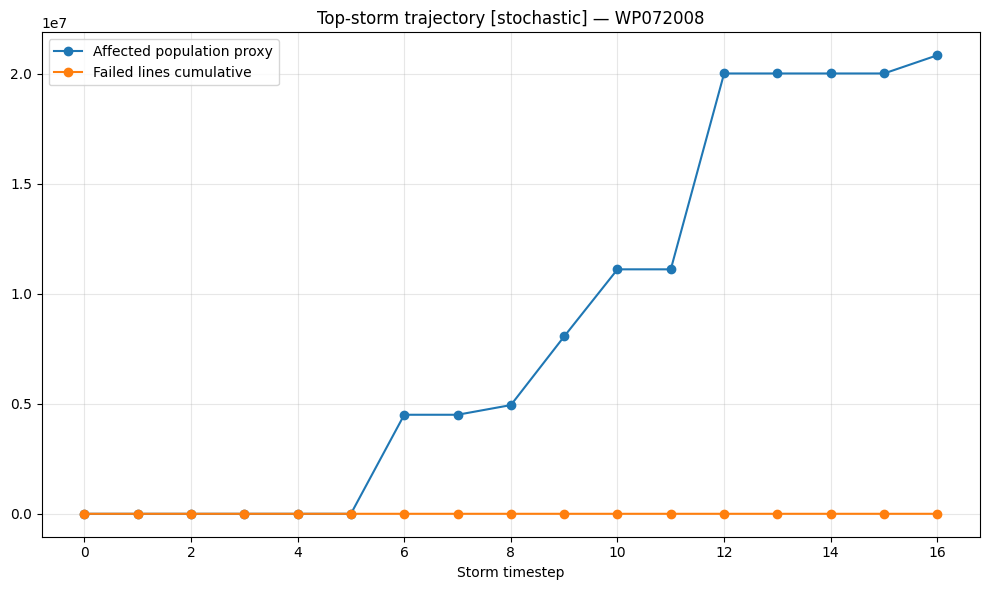

In [65]:
# Top-event dynamic animation and peak footprint
# Compare deterministic-top vs stochastic-top selection cleanly

top_storm_id_v5r = rank_df_v5r.iloc[0]["storm_id"]
top_storm_id_v5r_stoch = rank_df_v5r_stoch.iloc[0]["storm_id"]

print("Top deterministic v5r storm:", top_storm_id_v5r)
print("Top stochastic v5r storm:", top_storm_id_v5r_stoch)

# Choose which one to animate
USE_STOCHASTIC_TOP_STORM = True

if USE_STOCHASTIC_TOP_STORM:
    selected_top_storm_id = top_storm_id_v5r_stoch
    selected_label = "stochastic"
    rng_top = np.random.default_rng(2026)

    ts_top, steps_top = simulate_grid_impact_timeseries_v5r_stochastic(
        storm_id=selected_top_storm_id,
        ph_points=ph_points,
        line_df=line_df,
        line_samples=line_samples,
        buses=buses_nb,
        G_base=G_base,
        gen_bus_cap=gen_bus_cap,
        baseline_mw_per_person_proxy=baseline_stats["mw_per_person_proxy"],
        search_radius_km=SEARCH_RADIUS_KM,
        global_max_wind_kph=GLOBAL_MAX_WIND,
        fragility_h0=FAIL_THRESHOLD,
        fragility_k=18.0,
        rmax_km_default=RMAX_KM_DEFAULT,
        rmax_scaling=RMAX_SCALING,
        inner_core_floor=INNER_CORE_FLOOR,
        outer_decay_power=OUTER_DECAY_POWER,
        min_effective_wind_kph=MIN_EFFECTIVE_WIND_KPH,
        bus_pop_col="bus_pop_local_nb",
        min_relative_ratio_multi=MIN_RELATIVE_RATIO_MULTI,
        min_relative_ratio_single=MIN_RELATIVE_RATIO_SINGLE,
        min_total_gen_mw=MIN_TOTAL_GEN_MW,
        rng=rng_top,
    )
else:
    selected_top_storm_id = top_storm_id_v5r
    selected_label = "deterministic"

    ts_top, steps_top = simulate_grid_impact_timeseries_v5r(
        storm_id=selected_top_storm_id,
        ph_points=ph_points,
        line_df=line_df,
        line_samples=line_samples,
        buses=buses_nb,
        G_base=G_base,
        gen_bus_cap=gen_bus_cap,
        baseline_mw_per_person_proxy=baseline_stats["mw_per_person_proxy"],
        search_radius_km=SEARCH_RADIUS_KM,
        global_max_wind_kph=GLOBAL_MAX_WIND,
        fail_threshold=FAIL_THRESHOLD,
        rmax_km_default=RMAX_KM_DEFAULT,
        rmax_scaling=RMAX_SCALING,
        inner_core_floor=INNER_CORE_FLOOR,
        outer_decay_power=OUTER_DECAY_POWER,
        min_effective_wind_kph=MIN_EFFECTIVE_WIND_KPH,
        bus_pop_col="bus_pop_local_nb",
        min_relative_ratio_multi=MIN_RELATIVE_RATIO_MULTI,
        min_relative_ratio_single=MIN_RELATIVE_RATIO_SINGLE,
        min_total_gen_mw=MIN_TOTAL_GEN_MW,
    )

display(ts_top.head())
display(ts_top.tail())

top_gif_busimpact_canonical = OUTPUT_DIR / (
    f"storm_animation_top_{selected_label}_{selected_top_storm_id}.gif"
)

anim_top_busimpact_canonical = animate_storm_bus_impact_canonical(
    step_outputs=steps_top,
    pop_assignment=pop_assignment,
    H_pop_log=H_pop_log,
    xedges_pop=xedges_pop,
    yedges_pop=yedges_pop,
    out_gif_path=top_gif_busimpact_canonical,
    interval=700,
    show_search_radius=True,
    search_radius_km=SEARCH_RADIUS_KM,
)

print("Saved animation:", top_gif_busimpact_canonical.resolve())
HTML(anim_top_busimpact_canonical.to_jshtml())

# Peak-step footprint extraction
peak_idx = ts_top["affected_population_proxy"].idxmax()
peak_t = int(ts_top.loc[peak_idx, "t"])
peak_step = next(s for s in steps_top if s["t"] == peak_t)

peak_bus_service = peak_step["bus_state"][["bus_id", "served", "unserved"]].copy()

pop_impact_peak = pop_assignment.merge(
    peak_bus_service,
    left_on="nearest_bus_id",
    right_on="bus_id",
    how="left",
)
pop_impact_peak["unserved"] = pop_impact_peak["unserved"].fillna(False)
affected_cells = pop_impact_peak.loc[pop_impact_peak["unserved"]].copy()

affected_pop_peak = float(affected_cells["pop_value"].sum())

affected_by_bus_peak = (
    affected_cells.groupby("nearest_bus_id", as_index=False)
    .agg(
        affected_population_proxy=("pop_value", "sum"),
        n_affected_cells=("pop_value", "size"),
    )
    .rename(columns={"nearest_bus_id": "bus_id"})
)

bus_impact_peak = buses_nb.merge(affected_by_bus_peak, on="bus_id", how="left")
bus_impact_peak["affected_population_proxy"] = bus_impact_peak["affected_population_proxy"].fillna(0.0)
bus_impact_peak["n_affected_cells"] = bus_impact_peak["n_affected_cells"].fillna(0).astype(int)

bus_impact_peak = bus_impact_peak.merge(peak_bus_service, on="bus_id", how="left")
bus_impact_peak["served"] = bus_impact_peak["served"].fillna(False)
bus_impact_peak["unserved"] = bus_impact_peak["unserved"].fillna(False)

# Footprint map
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={"projection": ccrs.PlateCarree()})
setup_ph_map(
    ax,
    title=(
        f"Peak disruption footprint: {peak_step['record']['storm_name']} "
        f"({peak_step['record']['year']}) [{selected_label}]\n"
        f"Peak affected population proxy = {affected_pop_peak:,.0f}"
    ),
)
plot_lines(ax, line_df, color="gray", alpha=0.15, linewidth=0.5, zorder=2)
plot_buses(ax, buses_nb, size=8, color="black", alpha=0.20, label="All buses", zorder=3)

impact_plot = bus_impact_peak[bus_impact_peak["affected_population_proxy"] > 0].copy()
if not impact_plot.empty:
    size_scale = 20 + 220 * (
        impact_plot["affected_population_proxy"] / impact_plot["affected_population_proxy"].max()
    )
    ax.scatter(
        impact_plot["lon"],
        impact_plot["lat"],
        s=size_scale,
        alpha=0.55,
        label="Affected population proxy by bus",
        transform=ccrs.PlateCarree(),
        zorder=4,
    )

unserved_plot = bus_impact_peak[bus_impact_peak["unserved"]].copy()
if not unserved_plot.empty:
    ax.scatter(
        unserved_plot["lon"],
        unserved_plot["lat"],
        s=45,
        marker="x",
        alpha=0.95,
        label="Unserved buses",
        transform=ccrs.PlateCarree(),
        zorder=5,
    )

ax.legend()
plt.tight_layout()
plt.show()

display(
    bus_impact_peak[
        [
            "bus_id",
            "unserved",
            "bus_pop_local_nb",
            "affected_population_proxy",
            "n_affected_cells",
        ]
    ]
    .sort_values("affected_population_proxy", ascending=False)
    .head(25)
)

# Optional: show peak-step component table if available
if "component_table" in peak_step:
    display(
        peak_step["component_table"]
        .sort_values(["served_component", "population_proxy"], ascending=[True, False])
        .reset_index(drop=True)
        .head(25)
    )

# Optional: quick time-series summary plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(ts_top["t"], ts_top["affected_population_proxy"], marker="o", label="Affected population proxy")
ax.plot(ts_top["t"], ts_top["n_failed_lines_cumulative"], marker="o", label="Failed lines cumulative")
ax.set_title(f"Top-storm trajectory [{selected_label}] — {selected_top_storm_id}")
ax.set_xlabel("Storm timestep")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

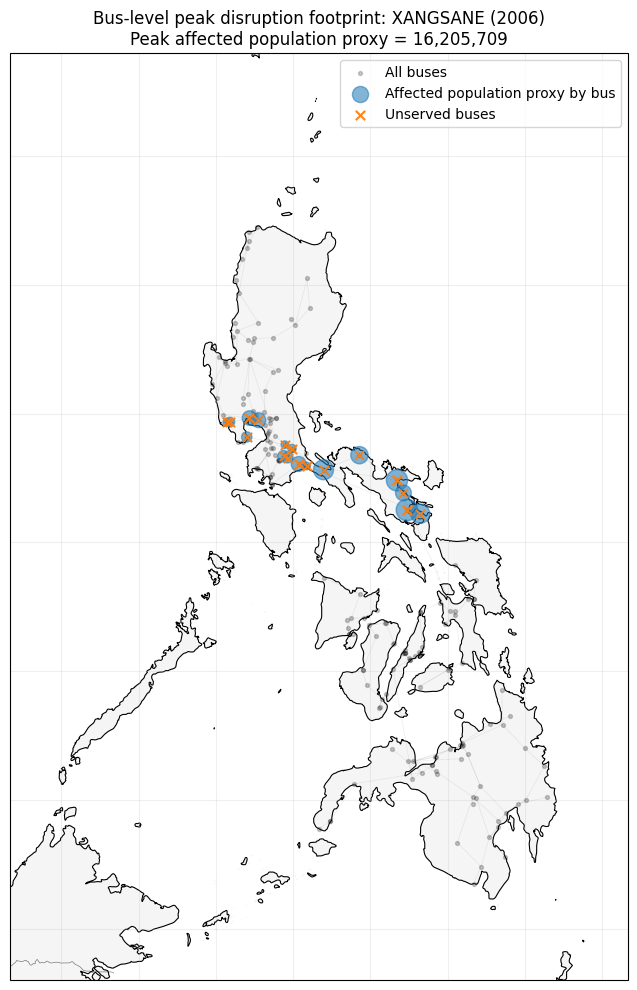

,bus_id,unserved,bus_pop_local_nb,affected_population_proxy,n_affected_cells
70,03DARAGA,True,2.358922e+06,2.358922e+06,4771
84,03NAGA,True,2.284200e+06,2.284200e+06,4775
73,03GUMACA,True,2.002189e+06,2.002189e+06,5829
63,03BACMANGP,True,1.790441e+06,1.790441e+06,3566
76,03LABO,True,1.452695e+06,1.452695e+06,4832
95,03TIWI-C,True,1.169394e+06,1.169394e+06,1619
93,03TAYABEHV,True,1.030816e+06,1.030816e+06,1081
36,01MALOLOS,True,1.010368e+06,1.010368e+06,413
6,01BALSIK,True,9.508022e+05,9.508022e+05,840
67,03CALAUAN,True,5.344531e+05,5.344531e+05,188


In [ ]:
peak_idx = ts_top_v5r["affected_population_proxy"].idxmax()
peak_t = int(ts_top_v5r.loc[peak_idx, "t"])
peak_step = next(s for s in steps_top_v5r if s["t"] == peak_t)

peak_bus_service = peak_step["bus_state"][["bus_id", "served", "unserved"]].copy()
pop_impact_peak = pop_assignment.merge(
    peak_bus_service,
    left_on="nearest_bus_id",
    right_on="bus_id",
    how="left",
)
pop_impact_peak["unserved"] = pop_impact_peak["unserved"].fillna(False)
affected_cells = pop_impact_peak.loc[pop_impact_peak["unserved"]].copy()

affected_pop_peak = affected_cells["pop_value"].sum()

affected_by_bus_peak = (
    affected_cells.groupby("nearest_bus_id", as_index=False)
    .agg(
        affected_population_proxy=("pop_value", "sum"),
        n_affected_cells=("pop_value", "size"),
    )
    .rename(columns={"nearest_bus_id": "bus_id"})
)

bus_impact_peak = buses_nb.merge(affected_by_bus_peak, on="bus_id", how="left")
bus_impact_peak["affected_population_proxy"] = bus_impact_peak["affected_population_proxy"].fillna(0.0)
bus_impact_peak["n_affected_cells"] = bus_impact_peak["n_affected_cells"].fillna(0).astype(int)
bus_impact_peak = bus_impact_peak.merge(peak_bus_service, on="bus_id", how="left")
bus_impact_peak["served"] = bus_impact_peak["served"].fillna(False)
bus_impact_peak["unserved"] = bus_impact_peak["unserved"].fillna(False)

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={"projection": ccrs.PlateCarree()})
setup_ph_map(
    ax,
    title=(
        f"Bus-level peak disruption footprint: {peak_step['record']['storm_name']} "
        f"({peak_step['record']['year']})\nPeak affected population proxy = {affected_pop_peak:,.0f}"
    ),
)
plot_lines(ax, line_df, color="gray", alpha=0.15, linewidth=0.5, zorder=2)
plot_buses(ax, buses_nb, size=8, color="black", alpha=0.20, label="All buses", zorder=3)

impact_plot = bus_impact_peak[bus_impact_peak["affected_population_proxy"] > 0].copy()
if not impact_plot.empty:
    size_scale = 20 + 220 * (impact_plot["affected_population_proxy"] / impact_plot["affected_population_proxy"].max())
    ax.scatter(
        impact_plot["lon"], impact_plot["lat"], s=size_scale, alpha=0.55,
        label="Affected population proxy by bus",
        transform=ccrs.PlateCarree(), zorder=4,
    )

unserved_plot = bus_impact_peak[bus_impact_peak["unserved"]].copy()
if not unserved_plot.empty:
    ax.scatter(
        unserved_plot["lon"], unserved_plot["lat"], s=45, marker="x", alpha=0.95,
        label="Unserved buses", transform=ccrs.PlateCarree(), zorder=5,
    )

ax.legend()
plt.tight_layout()
plt.show()

display(
    bus_impact_peak[
        ["bus_id", "unserved", "bus_pop_local_nb", "affected_population_proxy", "n_affected_cells"]
    ].sort_values("affected_population_proxy", ascending=False).head(25)
)

## Ensemble hotspot statistics

Hotspot storms processed: 323
Mode: stochastic


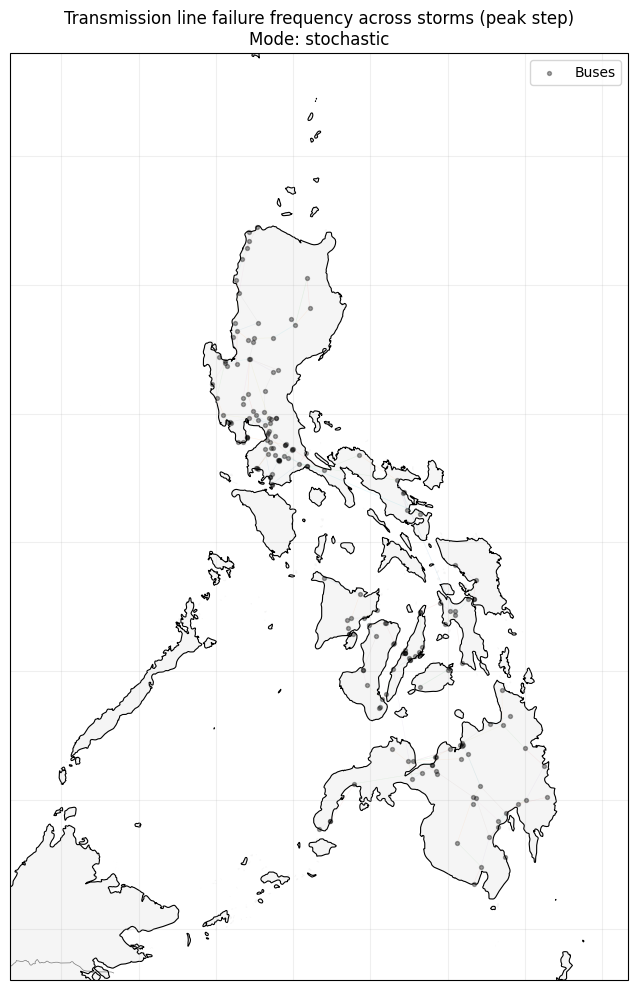

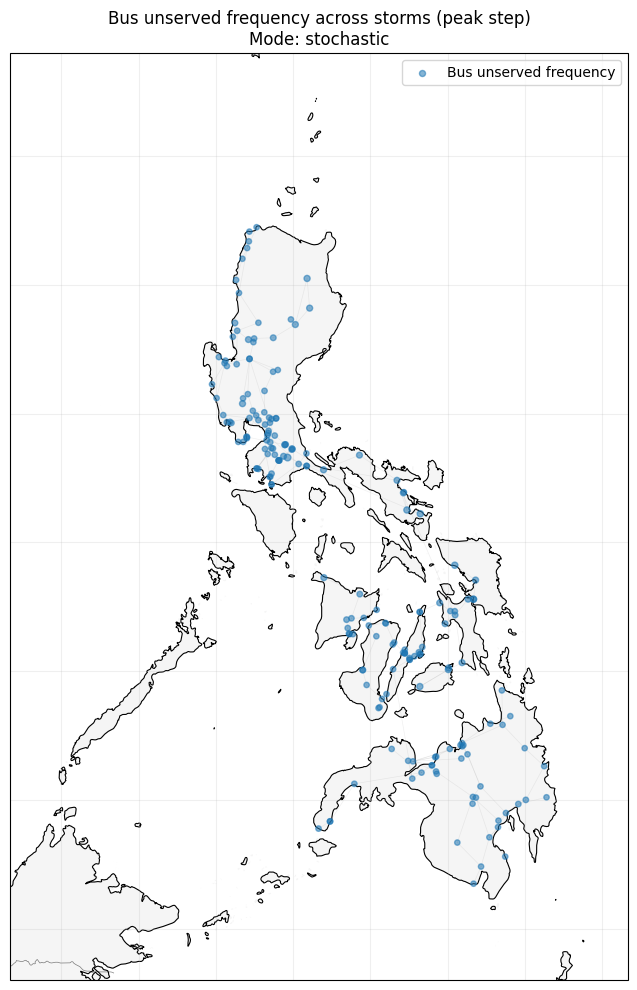

,line_id,bus0,bus1,failure_frequency
99,99,03BACMANGP,03PALAYAN,0.034056
100,100,03NAGA,04ORMOC,0.030960
97,97,03TIWI-C,03DARAGA,0.024768
22,22,01SNTGO,01TGEGARAO,0.021672
94,94,03NAGA,03DARAGA,0.021672
19,19,01BYOMBNG,01SNTGO,0.021672
98,98,03DARAGA,03BACMANGP,0.018576
101,101,03NAGA,03LABO,0.018576
11,11,01BAUANG,01LATRINI,0.018576
95,95,03NAGA,03TIWI-C,0.018576


,bus_id,bus_pop_local_nb,unserved_frequency
86,03PALAYAN,4.393862e+05,0.034056
63,03BACMANGP,1.790441e+06,0.021672
70,03DARAGA,2.358922e+06,0.021672
97,04CALBAYOG,2.327941e+06,0.021672
103,04STARITA,0.000000e+00,0.018576
13,01BPC,1.088207e+05,0.018576
54,01TGEGARAO,2.117532e+06,0.018576
136,07CORELLA,1.231223e+06,0.018576
102,04PARANAS,1.056476e+06,0.015480
95,03TIWI-C,1.169394e+06,0.015480


In [66]:
# Ensemble hotspot statistics
# Frequency with which lines fail / buses become unserved at each storm's peak step
# Uses deterministic or stochastic simulator depending on toggle below

USE_STOCHASTIC_HOTSPOTS = True
MAX_HOTSPOT_STORMS = None   # set to e.g. 30 for faster testing

line_fail_records = []
bus_unserved_records = []

storm_iter = storm_meta.copy()
if MAX_HOTSPOT_STORMS is not None:
    storm_iter = storm_iter.head(MAX_HOTSPOT_STORMS).copy()

for storm_counter, (_, meta) in enumerate(storm_iter.iterrows()):
    storm_id = meta["storm_id"]

    try:
        if USE_STOCHASTIC_HOTSPOTS:
            rng_hot = np.random.default_rng(50000 + storm_counter)

            ts_df_use, step_outputs = simulate_grid_impact_timeseries_v5r_stochastic(
                storm_id=storm_id,
                ph_points=ph_points,
                line_df=line_df,
                line_samples=line_samples,
                buses=buses_nb,
                G_base=G_base,
                gen_bus_cap=gen_bus_cap,
                baseline_mw_per_person_proxy=baseline_stats["mw_per_person_proxy"],
                search_radius_km=SEARCH_RADIUS_KM,
                global_max_wind_kph=GLOBAL_MAX_WIND,
                fragility_h0=FAIL_THRESHOLD,
                fragility_k=18.0,
                rmax_km_default=RMAX_KM_DEFAULT,
                rmax_scaling=RMAX_SCALING,
                inner_core_floor=INNER_CORE_FLOOR,
                outer_decay_power=OUTER_DECAY_POWER,
                min_effective_wind_kph=MIN_EFFECTIVE_WIND_KPH,
                bus_pop_col="bus_pop_local_nb",
                min_relative_ratio_multi=MIN_RELATIVE_RATIO_MULTI,
                min_relative_ratio_single=MIN_RELATIVE_RATIO_SINGLE,
                min_total_gen_mw=MIN_TOTAL_GEN_MW,
                rng=rng_hot,
            )
        else:
            ts_df_use, step_outputs = simulate_grid_impact_timeseries_v5r(
                storm_id=storm_id,
                ph_points=ph_points,
                line_df=line_df,
                line_samples=line_samples,
                buses=buses_nb,
                G_base=G_base,
                gen_bus_cap=gen_bus_cap,
                baseline_mw_per_person_proxy=baseline_stats["mw_per_person_proxy"],
                search_radius_km=SEARCH_RADIUS_KM,
                global_max_wind_kph=GLOBAL_MAX_WIND,
                fail_threshold=FAIL_THRESHOLD,
                rmax_km_default=RMAX_KM_DEFAULT,
                rmax_scaling=RMAX_SCALING,
                inner_core_floor=INNER_CORE_FLOOR,
                outer_decay_power=OUTER_DECAY_POWER,
                min_effective_wind_kph=MIN_EFFECTIVE_WIND_KPH,
                bus_pop_col="bus_pop_local_nb",
                min_relative_ratio_multi=MIN_RELATIVE_RATIO_MULTI,
                min_relative_ratio_single=MIN_RELATIVE_RATIO_SINGLE,
                min_total_gen_mw=MIN_TOTAL_GEN_MW,
            )

        if ts_df_use.empty:
            continue

        peak_idx = ts_df_use["affected_population_proxy"].idxmax()
        peak_t = int(ts_df_use.loc[peak_idx, "t"])
        peak_step = next(s for s in step_outputs if s["t"] == peak_t)

        lf_peak = peak_step["lf"][["line_id", "failed_cumulative"]].copy()
        lf_peak["storm_id"] = storm_id
        line_fail_records.append(lf_peak)

        bus_peak = peak_step["bus_state"][["bus_id", "unserved"]].copy()
        bus_peak["storm_id"] = storm_id
        bus_unserved_records.append(bus_peak)

    except Exception as exc:
        print(f"Skipping hotspot stats for {storm_id}: {exc}")

if not line_fail_records:
    raise ValueError("No line-failure hotspot records were produced.")
if not bus_unserved_records:
    raise ValueError("No bus-unserved hotspot records were produced.")

line_fail_all = pd.concat(line_fail_records, ignore_index=True)
line_fail_freq = (
    line_fail_all.groupby("line_id", as_index=False)["failed_cumulative"]
    .mean()
    .rename(columns={"failed_cumulative": "failure_frequency"})
)

line_fail_map = line_df.merge(line_fail_freq, on="line_id", how="left")
line_fail_map["failure_frequency"] = line_fail_map["failure_frequency"].fillna(0.0)

bus_unserved_all = pd.concat(bus_unserved_records, ignore_index=True)
bus_unserved_freq = (
    bus_unserved_all.groupby("bus_id", as_index=False)["unserved"]
    .mean()
    .rename(columns={"unserved": "unserved_frequency"})
)

bus_unserved_map = buses_nb.merge(bus_unserved_freq, on="bus_id", how="left")
bus_unserved_map["unserved_frequency"] = bus_unserved_map["unserved_frequency"].fillna(0.0)

print("Hotspot storms processed:", len(storm_iter))
print("Mode:", "stochastic" if USE_STOCHASTIC_HOTSPOTS else "deterministic")

# Line-failure frequency map
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={"projection": ccrs.PlateCarree()})
setup_ph_map(
    ax,
    title=(
        "Transmission line failure frequency across storms (peak step)\n"
        f"Mode: {'stochastic' if USE_STOCHASTIC_HOTSPOTS else 'deterministic'}"
    ),
)

for _, row in line_fail_map.iterrows():
    lw = 0.4 + 3.0 * row["failure_frequency"]
    alpha = 0.08 + 0.85 * row["failure_frequency"]
    ax.plot(
        [row["lon0"], row["lon1"]],
        [row["lat0"], row["lat1"]],
        linewidth=lw,
        alpha=alpha,
        transform=ccrs.PlateCarree(),
        zorder=3,
    )

plot_buses(ax, buses_nb, size=8, color="black", alpha=0.35, label="Buses", zorder=4)
ax.legend()
plt.tight_layout()
plt.show()

# Bus-unserved frequency map
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={"projection": ccrs.PlateCarree()})
setup_ph_map(
    ax,
    title=(
        "Bus unserved frequency across storms (peak step)\n"
        f"Mode: {'stochastic' if USE_STOCHASTIC_HOTSPOTS else 'deterministic'}"
    ),
)

plot_lines(ax, line_df, color="gray", alpha=0.12, linewidth=0.5, zorder=1)
size_scale = 15 + 240 * bus_unserved_map["unserved_frequency"]

ax.scatter(
    bus_unserved_map["lon"],
    bus_unserved_map["lat"],
    s=size_scale,
    alpha=0.55,
    label="Bus unserved frequency",
    transform=ccrs.PlateCarree(),
    zorder=3,
)

ax.legend()
plt.tight_layout()
plt.show()

display(
    line_fail_map[
        ["line_id", "bus0", "bus1", "failure_frequency"]
    ]
    .sort_values("failure_frequency", ascending=False)
    .head(25)
)

display(
    bus_unserved_map[
        ["bus_id", "bus_pop_local_nb", "unserved_frequency"]
    ]
    .sort_values("unserved_frequency", ascending=False)
    .head(25)
)

In [67]:
# Save outputs

out_csv_v4b = OUTPUT_DIR / "storm_rank_grid_failure_timeseries_v4b_sampled_lines.csv"
out_csv_v5r = OUTPUT_DIR / "storm_rank_grid_failure_timeseries_v5r_sampled_lines.csv"
out_csv_v5r_stoch = OUTPUT_DIR / "storm_rank_grid_failure_timeseries_v5r_stochastic_sampled_lines.csv"

rank_df_v4b.to_csv(out_csv_v4b, index=False)
rank_df_v5r.to_csv(out_csv_v5r, index=False)

if "rank_df_v5r_stoch" in globals() and not rank_df_v5r_stoch.empty:
    rank_df_v5r_stoch.to_csv(out_csv_v5r_stoch, index=False)

for sid, ts_df_v4b in storm_ts_store_v4b.items():
    ts_path = OUTPUT_DIR / f"storm_timeseries_v4b_{sid}.csv"
    ts_df_v4b.to_csv(ts_path, index=False)

for sid, ts_df_v5r in storm_ts_store_v5r.items():
    ts_path = OUTPUT_DIR / f"storm_timeseries_v5r_{sid}.csv"
    ts_df_v5r.to_csv(ts_path, index=False)

if "storm_ts_store_v5r_stoch" in globals():
    for sid, ts_df_v5r_stoch in storm_ts_store_v5r_stoch.items():
        ts_path = OUTPUT_DIR / f"storm_timeseries_v5r_stochastic_{sid}.csv"
        ts_df_v5r_stoch.to_csv(ts_path, index=False)

if "compare_v4b_v5r" in globals():
    compare_v4b_v5r.to_csv(OUTPUT_DIR / "compare_v4b_vs_v5r.csv", index=False)

if "compare_det_stoch" in globals():
    compare_det_stoch.to_csv(OUTPUT_DIR / "compare_v5r_det_vs_stoch.csv", index=False)

if "line_fail_map" in globals():
    line_fail_map.to_csv(OUTPUT_DIR / "line_failure_frequency_map.csv", index=False)

if "bus_unserved_map" in globals():
    bus_unserved_map.to_csv(OUTPUT_DIR / "bus_unserved_frequency_map.csv", index=False)

if "ensemble_summary_demo" in globals():
    ensemble_summary_demo.to_csv(OUTPUT_DIR / "ensemble_summary_demo.csv", index=False)

print("Saved v4b ranking:", out_csv_v4b.resolve())
print("Saved v5r deterministic ranking:", out_csv_v5r.resolve())

if out_csv_v5r_stoch.exists():
    print("Saved v5r stochastic ranking:", out_csv_v5r_stoch.resolve())

print("Saved outputs to:", OUTPUT_DIR.resolve())

# Quick manifest
saved_files = sorted([p.name for p in OUTPUT_DIR.glob("*")])
print("\nOutput directory contents:")
for fname in saved_files[:200]:
    print(" -", fname)

Saved v4b ranking: /home/krawalker/coding/KRITIS-PH/outputs/storm_rank_grid_failure_timeseries_v4b_sampled_lines.csv
Saved v5r deterministic ranking: /home/krawalker/coding/KRITIS-PH/outputs/storm_rank_grid_failure_timeseries_v5r_sampled_lines.csv
Saved v5r stochastic ranking: /home/krawalker/coding/KRITIS-PH/outputs/storm_rank_grid_failure_timeseries_v5r_stochastic_sampled_lines.csv
Saved outputs to: /home/krawalker/coding/KRITIS-PH/outputs

Output directory contents:
 - bus_unserved_frequency_map.csv
 - compare_v4b_vs_v5r.csv
 - compare_v5r_det_vs_stoch.csv
 - ensemble_summary_demo.csv
 - geo_land_sea_scores.csv
 - line_failure_frequency_map.csv
 - presentation_figures
 - slide_anim_WP182006.gif
 - storm_animation_WP012001.gif
 - storm_animation_top_WP312013.gif
 - storm_animation_top_stochastic_WP072008.gif
 - storm_animation_top_v3_WP312013.gif
 - storm_animation_top_v4b_WP182006.gif
 - storm_animation_top_v5r_WP182006.gif
 - storm_animation_top_v5r_busimpact_canonical_WP182006.gif


## Limitations

This screening model intentionally does **not** represent:
- AC/DC power flow
- line loading, dispatch, voltage stability, or operational redispatch
- probabilistic fragility functions
- restoration dynamics
- event-year-specific network build-out
- direct outage validation against observed blackout records

In **v5r**, service adequacy is a proxy based on installed generation capacity relative to a bus-attached population proxy, normalized against the intact-system benchmark. It is useful as a **screening construct**, not as a full adequacy or outage model.
